# IBM Employee Attrition Prediction
**Group 5**  
**Project:** Enterprise Resource Planning (HR problem).  
**Goal:** Build a classification model to predict employee attrition, identify key risk factors, and inform HR retention strategy.  
**Dataset:** IBM HR Analytics Employee Attrition.  
**Approach:** Logistic Regression (baseline) vs XGBoost (main model)

# Part I. Understanding the data

## 1.1 Import modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, cross_val_predict, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, fbeta_score, precision_score, recall_score,
    log_loss, brier_score_loss
)
from sklearn.calibration import calibration_curve

from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import shap

import joblib, json, os
from datetime import datetime

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

## 1.2 Data collection and initial inspection

In [2]:
df_raw = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df_raw.copy()
TARGET_COL = 'Attrition'

In [3]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.dtypes.value_counts()

int64    26
str       9
Name: count, dtype: int64

In [6]:
df[TARGET_COL].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### Column categorization

The 35 columns are grouped into 7 semantic categories based on domain knowledge of HR analytics:

In [7]:
COL_CATEGORIES = {
    'demographic': ['Age', 'Gender', 'MaritalStatus', 'Education', 'EducationField'],
    'job': ['Department', 'JobRole', 'JobLevel', 'JobInvolvement', 'BusinessTravel', 'OverTime'],
    'compensation': ['MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate',  'PercentSalaryHike', 'StockOptionLevel'],
    'satisfaction': ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance'],
    'performance': ['PerformanceRating', 'TrainingTimesLastYear'],
    'tenure': ['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked'],
    'other': ['DistanceFromHome'],
    'constant': ['EmployeeCount', 'Over18', 'StandardHours'],
    'identifier': ['EmployeeNumber']}

category_summary = pd.DataFrame([
    {'category': cat, 'n_cols': len(cols), 'columns': ', '.join(cols)}
    for cat, cols in COL_CATEGORIES.items()
])
category_summary

,category,n_cols,columns
0,demographic,5,"Age, Gender, MaritalStatus, Education, Educati..."
1,job,6,"Department, JobRole, JobLevel, JobInvolvement,..."
2,compensation,6,"MonthlyIncome, DailyRate, HourlyRate, MonthlyR..."
3,satisfaction,4,"EnvironmentSatisfaction, JobSatisfaction, Rela..."
4,performance,2,"PerformanceRating, TrainingTimesLastYear"
5,tenure,6,"TotalWorkingYears, YearsAtCompany, YearsInCurr..."
6,other,1,DistanceFromHome
7,constant,3,"EmployeeCount, Over18, StandardHours"
8,identifier,1,EmployeeNumber


## 1.3 Data quality assessment

In [8]:
def data_quality_report(df):
    rep = pd.DataFrame(index=df.columns)
    rep['dtype'] = df.dtypes.astype(str)
    rep['n_missing'] = df.isnull().sum()
    rep['pct_missing'] = (df.isnull().sum()/len(df)*100).round(2)
    rep['n_unique'] = df.nunique()
    rep['pct_unique'] = (df.nunique()/len(df) * 100).round(2)
    rep['is_constant'] = df.nunique() == 1
    rep['high_cardinality'] = rep['pct_unique'] > 90
    return rep

quality_report = data_quality_report(df)
quality_report

,dtype,n_missing,pct_missing,n_unique,pct_unique,is_constant,high_cardinality
Age,int64,0,0.0,43,2.93,False,False
Attrition,str,0,0.0,2,0.14,False,False
BusinessTravel,str,0,0.0,3,0.20,False,False
DailyRate,int64,0,0.0,886,60.27,False,False
Department,str,0,0.0,3,0.20,False,False
DistanceFromHome,int64,0,0.0,29,1.97,False,False
Education,int64,0,0.0,5,0.34,False,False
EducationField,str,0,0.0,6,0.41,False,False
EmployeeCount,int64,0,0.0,1,0.07,True,False
EmployeeNumber,int64,0,0.0,1470,100.00,False,True


In [9]:
issues = {
    'Constant columns': quality_report[quality_report['is_constant']].index.tolist(),
    'High cardinality (>90%)': quality_report[quality_report['high_cardinality']].index.tolist(),
    'Missing > 30%': quality_report[quality_report['pct_missing'] > 30].index.tolist(),
    'Total duplicates': [df.duplicated().sum()]
}
pd.DataFrame({k: pd.Series(v) for k, v in issues.items()})

,Constant columns,High cardinality (>90%),Missing > 30%,Total duplicates
0,EmployeeCount,EmployeeNumber,NaN,0.0
1,Over18,MonthlyIncome,NaN,NaN
2,StandardHours,MonthlyRate,NaN,NaN


## 1.4 Data cleaning

### 1.4.1 Drop constant and identifier columns

In [10]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df.shape

(1470, 31)

### 1.4.2 Target variable encoding

In [11]:
df[TARGET_COL] = df[TARGET_COL].map({'Yes':1,'No':0})
df[TARGET_COL].value_counts(normalize=True).round(4)*100

Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64

### 1.4.3 Missing values check

In [12]:
missing_summary = df.isnull().sum()
missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values detected"

'No missing values detected'

### 1.4.4 Duplicates

In [13]:
n_dup = df.duplicated().sum()
if n_dup > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
n_dup

np.int64(0)

### 1.4.5 Datatype verification

In [14]:
num_cols = df.select_dtypes(include=np.number).columns.drop(TARGET_COL).tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

pd.DataFrame({
    'numerical': pd.Series(num_cols),
    'categorical': pd.Series(cat_cols)
})

,numerical,categorical
0,Age,BusinessTravel
1,DailyRate,Department
2,DistanceFromHome,EducationField
3,Education,Gender
4,EnvironmentSatisfaction,JobRole
5,HourlyRate,MaritalStatus
6,JobInvolvement,OverTime
7,JobLevel,NaN
8,JobSatisfaction,NaN
9,MonthlyIncome,NaN


# Part II. Data exploration

## 2.1 Descriptive statistics

### 2.1.1 Numerical features summary

In [15]:
desc_num = df[num_cols].describe().T
desc_num['skewness'] = df[num_cols].skew()
desc_num['kurtosis'] = df[num_cols].kurtosis()
desc_num['cv'] = (desc_num['std'] / desc_num['mean']).round(4)
desc_num = desc_num.round(3)
desc_num

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv
Age,1470.0,36.924,9.135,18.0,30.0,36.0,43.00,60.0,0.413,-0.404,0.247
DailyRate,1470.0,802.486,403.509,102.0,465.0,802.0,1157.00,1499.0,-0.004,-1.204,0.503
DistanceFromHome,1470.0,9.193,8.107,1.0,2.0,7.0,14.00,29.0,0.958,-0.225,0.882
Education,1470.0,2.913,1.024,1.0,2.0,3.0,4.00,5.0,-0.290,-0.559,0.352
EnvironmentSatisfaction,1470.0,2.722,1.093,1.0,2.0,3.0,4.00,4.0,-0.322,-1.203,0.402
HourlyRate,1470.0,65.891,20.329,30.0,48.0,66.0,83.75,100.0,-0.032,-1.196,0.308
JobInvolvement,1470.0,2.730,0.712,1.0,2.0,3.0,3.00,4.0,-0.498,0.271,0.261
JobLevel,1470.0,2.064,1.107,1.0,1.0,2.0,3.00,5.0,1.025,0.399,0.536
JobSatisfaction,1470.0,2.729,1.103,1.0,2.0,3.0,4.00,4.0,-0.330,-1.222,0.404
MonthlyIncome,1470.0,6502.931,4707.957,1009.0,2911.0,4919.0,8379.00,19999.0,1.370,1.005,0.724


In [16]:
desc_num.to_csv("results/descriptive_numerical.csv")

### 2.1.2 Distribution shape classification

In [17]:
shape_summary = []
for col in num_cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        shape = 'symmetric'
    elif skew > 1:
        shape = 'right_skewed'
    elif skew < -1:
        shape = 'left_skewed'
    else:
        shape = 'slightly_skewed'
    shape_summary.append({'feature': col, 'skewness': round(skew, 3), 'shape': shape})

shape_df = pd.DataFrame(shape_summary).sort_values('skewness', ascending=False)
shape_df

,feature,skewness,shape
21,YearsSinceLastPromotion,1.984,right_skewed
13,PerformanceRating,1.922,right_skewed
19,YearsAtCompany,1.765,right_skewed
9,MonthlyIncome,1.370,right_skewed
16,TotalWorkingYears,1.117,right_skewed
11,NumCompaniesWorked,1.026,right_skewed
7,JobLevel,1.025,right_skewed
15,StockOptionLevel,0.969,slightly_skewed
2,DistanceFromHome,0.958,slightly_skewed
20,YearsInCurrentRole,0.917,slightly_skewed


### 2.1.3 Categorical features frequency

In [18]:
for col in cat_cols:
    freq = df[col].value_counts(normalize=True).round(4)*100
    freq.name = f"{col} (%)"
    display(freq.to_frame())

,BusinessTravel (%)
BusinessTravel,
Travel_Rarely,70.95
Travel_Frequently,18.84
Non-Travel,10.20


,Department (%)
Department,
Research & Development,65.37
Sales,30.34
Human Resources,4.29


,EducationField (%)
EducationField,
Life Sciences,41.22
Medical,31.56
Marketing,10.82
Technical Degree,8.98
Other,5.58
Human Resources,1.84


,Gender (%)
Gender,
Male,60.0
Female,40.0


,JobRole (%)
JobRole,
Sales Executive,22.18
Research Scientist,19.86
Laboratory Technician,17.62
Manufacturing Director,9.86
Healthcare Representative,8.91
Manager,6.94
Sales Representative,5.65
Research Director,5.44
Human Resources,3.54


,MaritalStatus (%)
MaritalStatus,
Married,45.78
Single,31.97
Divorced,22.24


,OverTime (%)
OverTime,
No,71.7
Yes,28.3


### 2.1.4 Target variable analysis

In [19]:
attrition_rate = df[TARGET_COL].mean()*100
counts = df[TARGET_COL].value_counts()
imbalance_ratio = counts[0]/counts[1]

pd.DataFrame({
    'metric': ['Total Employees', 'Stayed', 'Left', 'Attrition Rate', 'Imbalance Ratio'],
    'value':  [len(df), counts[0], counts[1], round(attrition_rate, 2), round(imbalance_ratio, 2)]
})

,metric,value
0,Total Employees,1470.00
1,Stayed,1233.00
2,Left,237.00
3,Attrition Rate,16.12
4,Imbalance Ratio,5.20


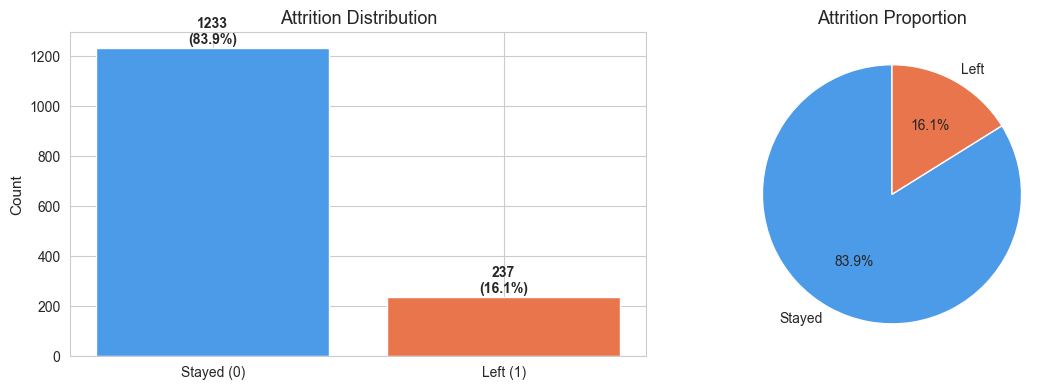

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Stayed (0)', 'Left (1)'], counts.values, color=['#4C9BE8', '#E8754C'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title(f"Attrition Distribution")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=['Stayed', 'Left'], autopct='%1.1f%%',
            colors=['#4C9BE8', '#E8754C'], startangle=90)
axes[1].set_title("Attrition Proportion")

plt.tight_layout()
plt.savefig("results/target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Exploratory data analysis (EDA)

### 2.2.1 Univariate analysis: Numerical features

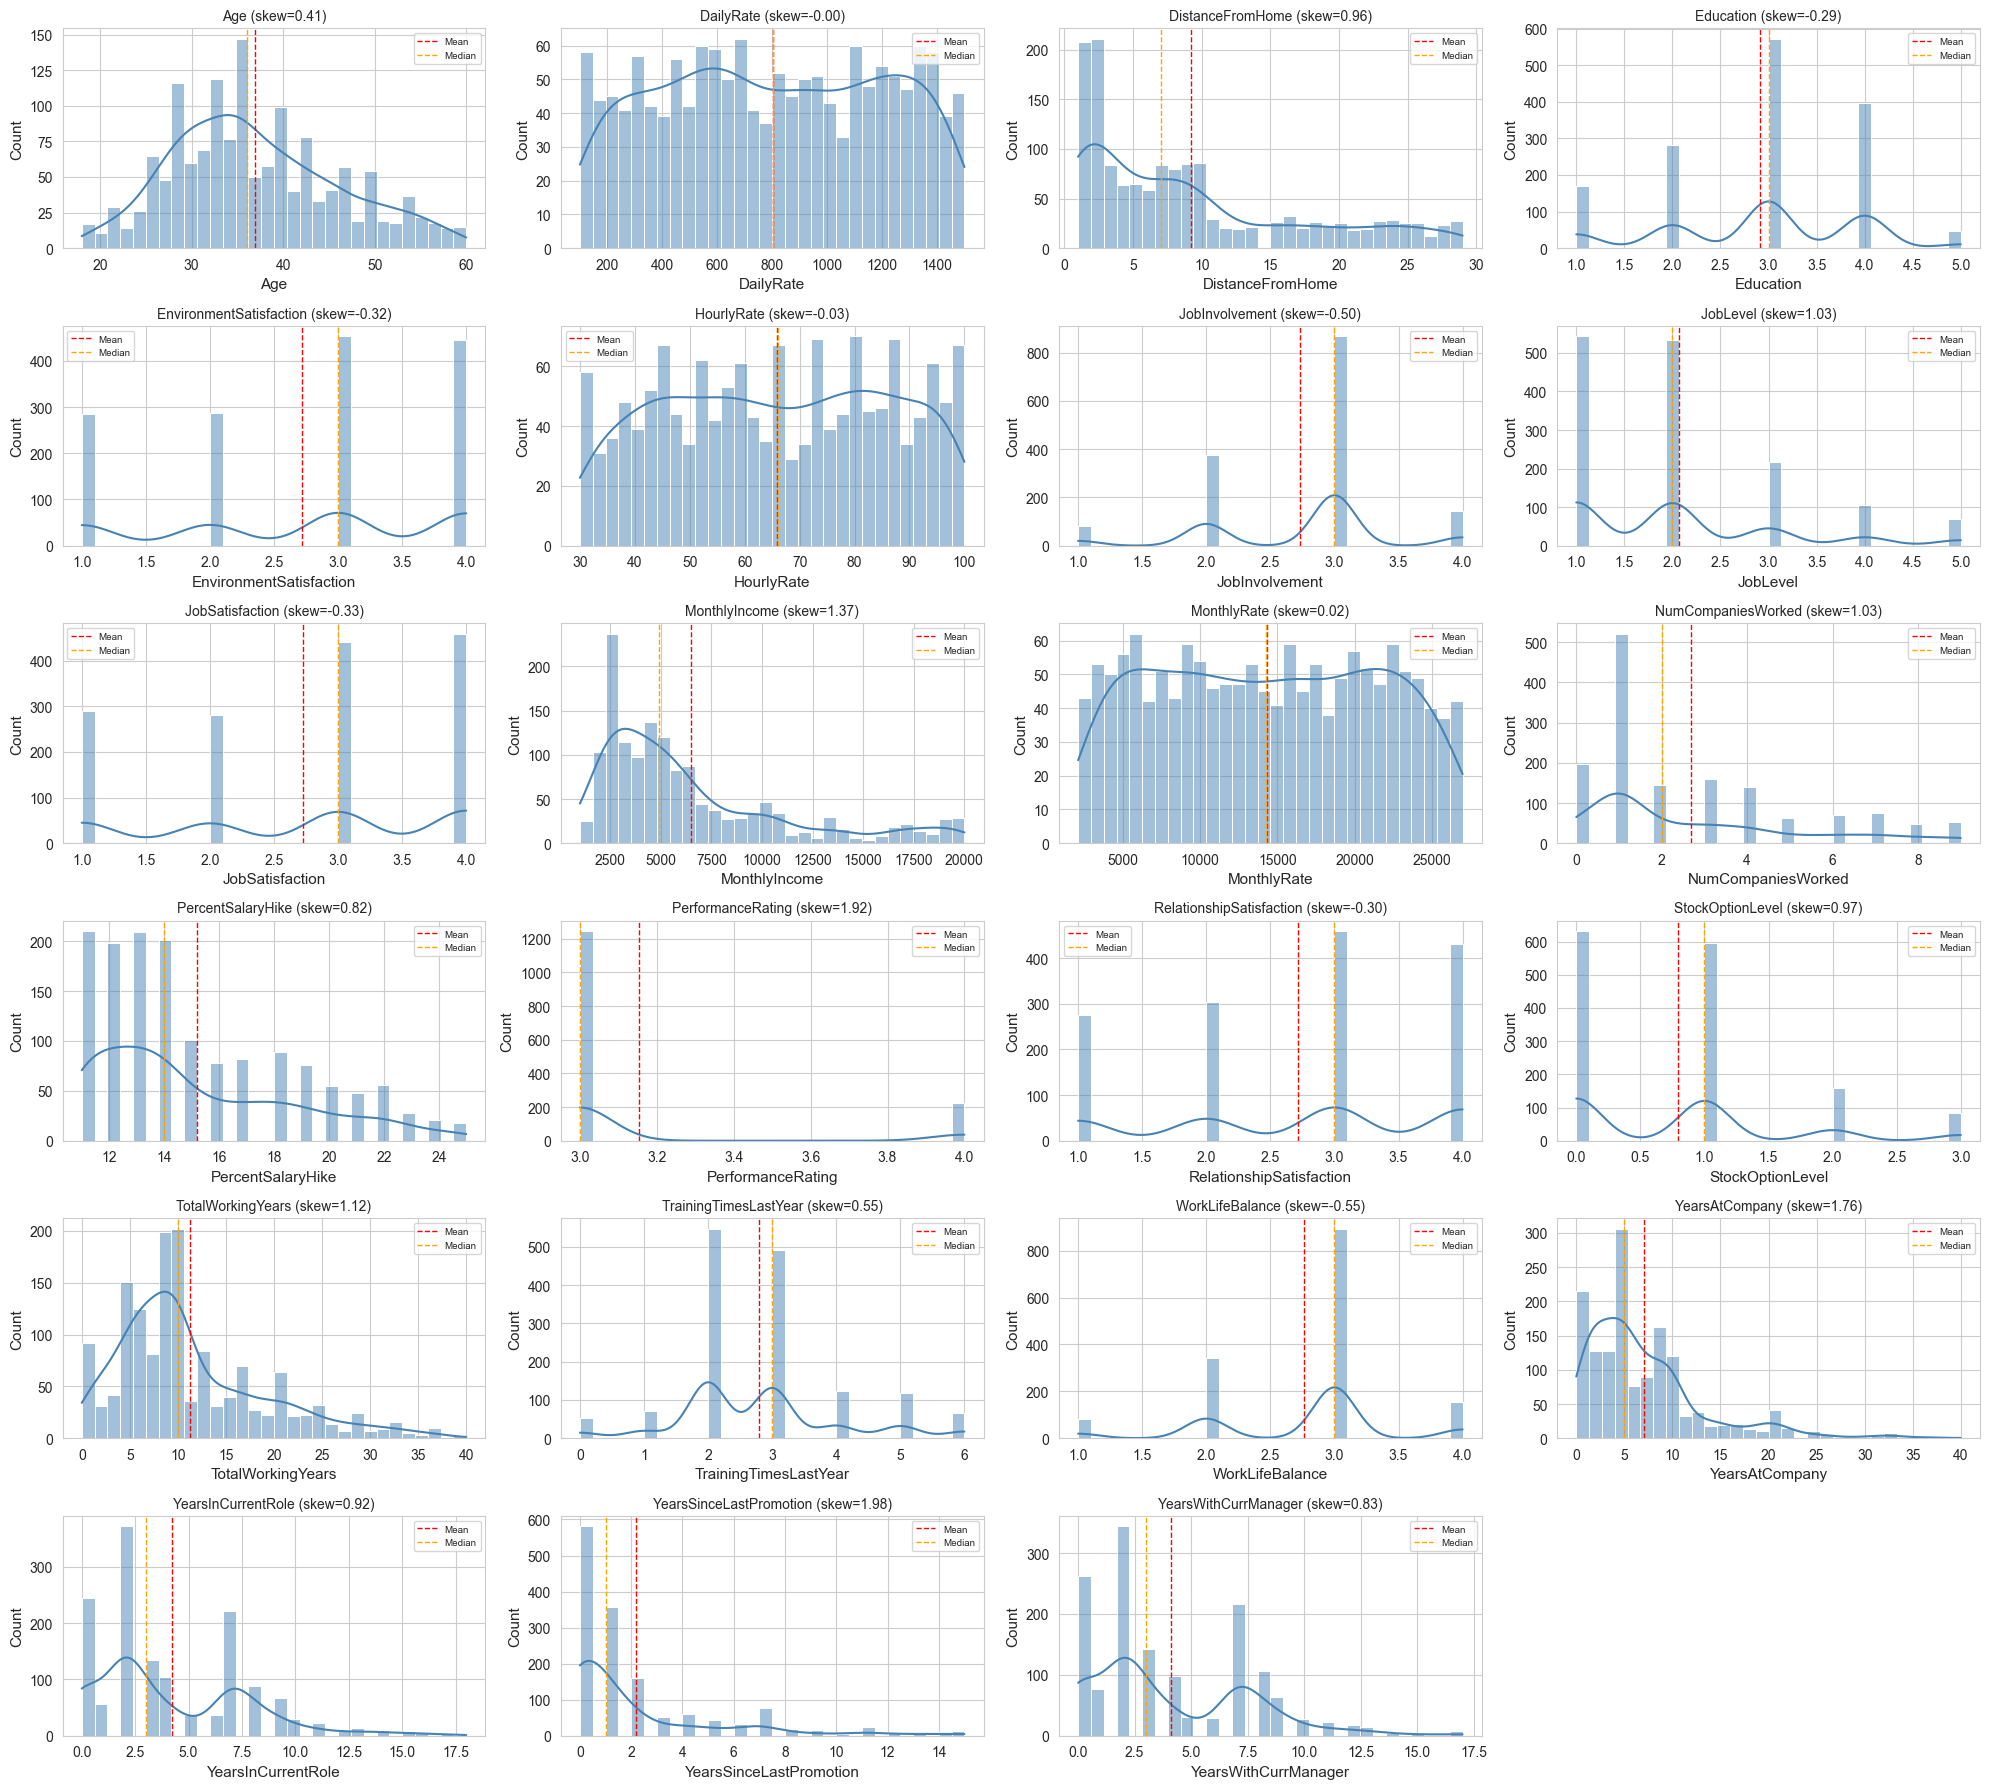

In [21]:
n_cols_grid = 4
n_rows_grid = (len(num_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.axvline(df[col].mean(),   color='red',    ls='--', lw=1, label='Mean')
    ax.axvline(df[col].median(), color='orange', ls='--', lw=1, label='Median')
    ax.set_title(f"{col} (skew={df[col].skew():.2f})", fontsize=10)
    ax.legend(fontsize=7)
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("results/eda_univariate.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.2.2 Bivariate analysis: Numerical features vs Attrition

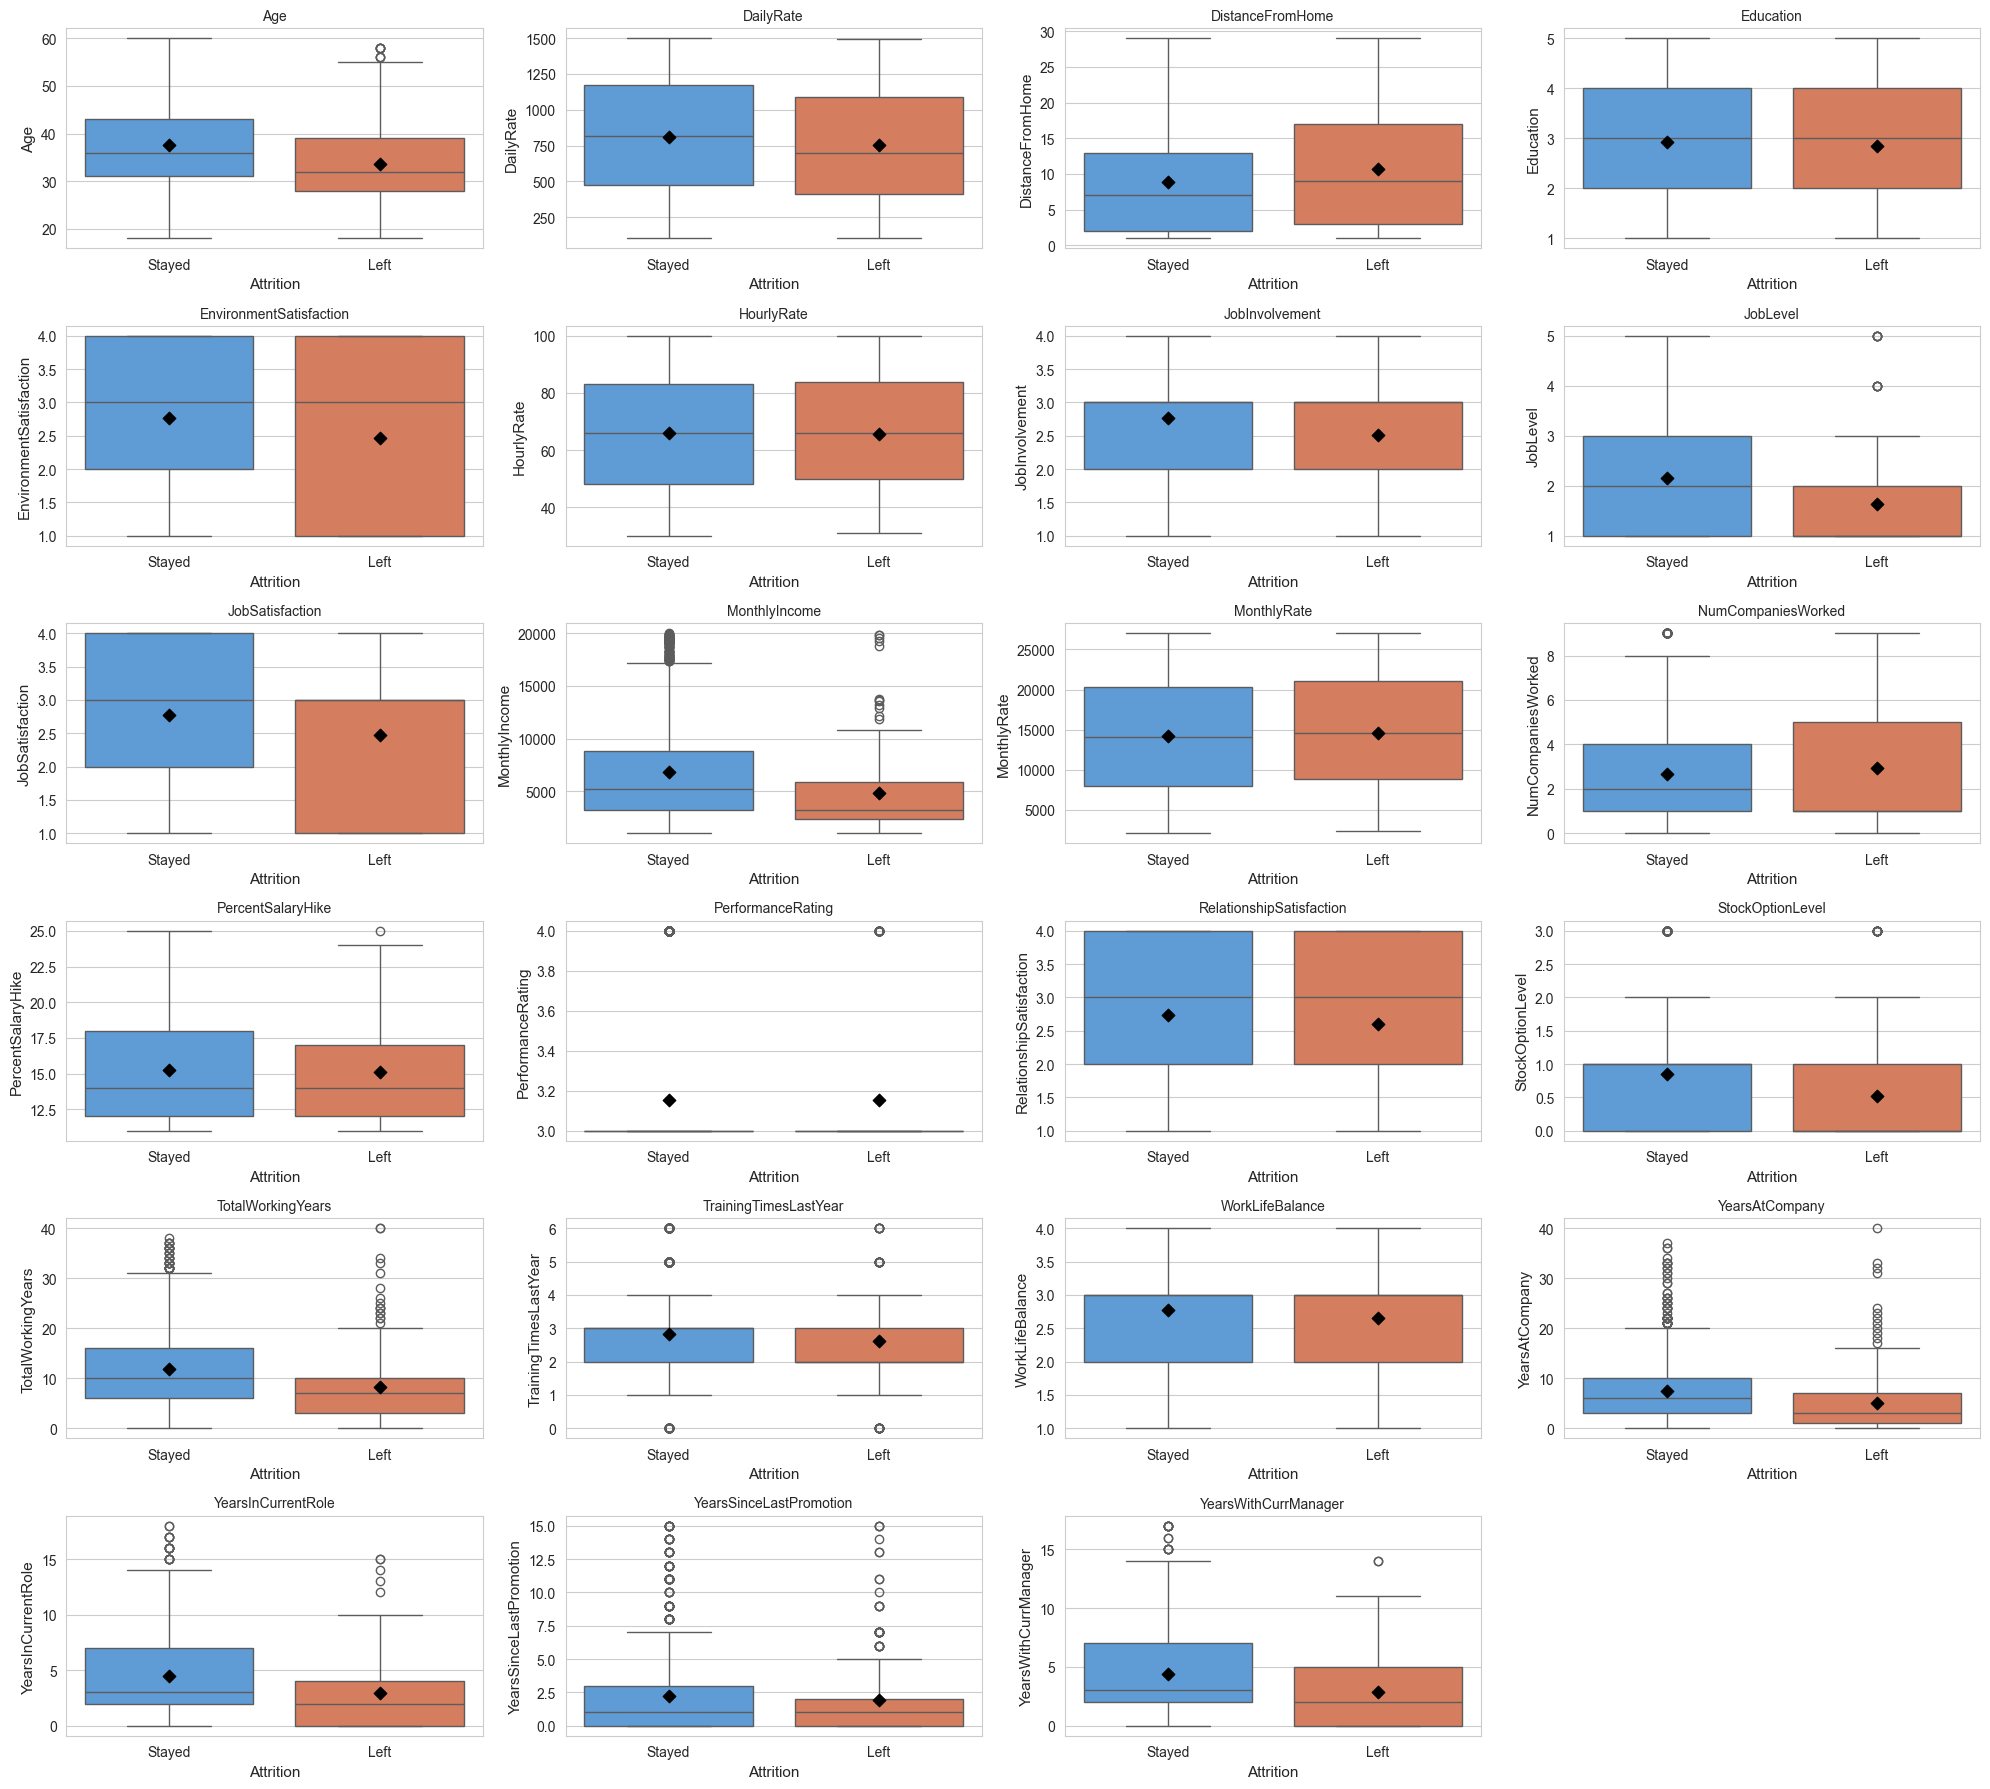

In [22]:
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=TARGET_COL, y=col, data=df, ax=ax,
                hue=TARGET_COL, palette=['#4C9BE8', '#E8754C'], legend=False)
    means = df.groupby(TARGET_COL)[col].mean()
    ax.scatter([0, 1], means, marker='D', s=40, color='black', zorder=3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Stayed', 'Left'])
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("results/eda_bivariate_num.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.2.3 Bivariate analysis: Categorical features vs Attrition

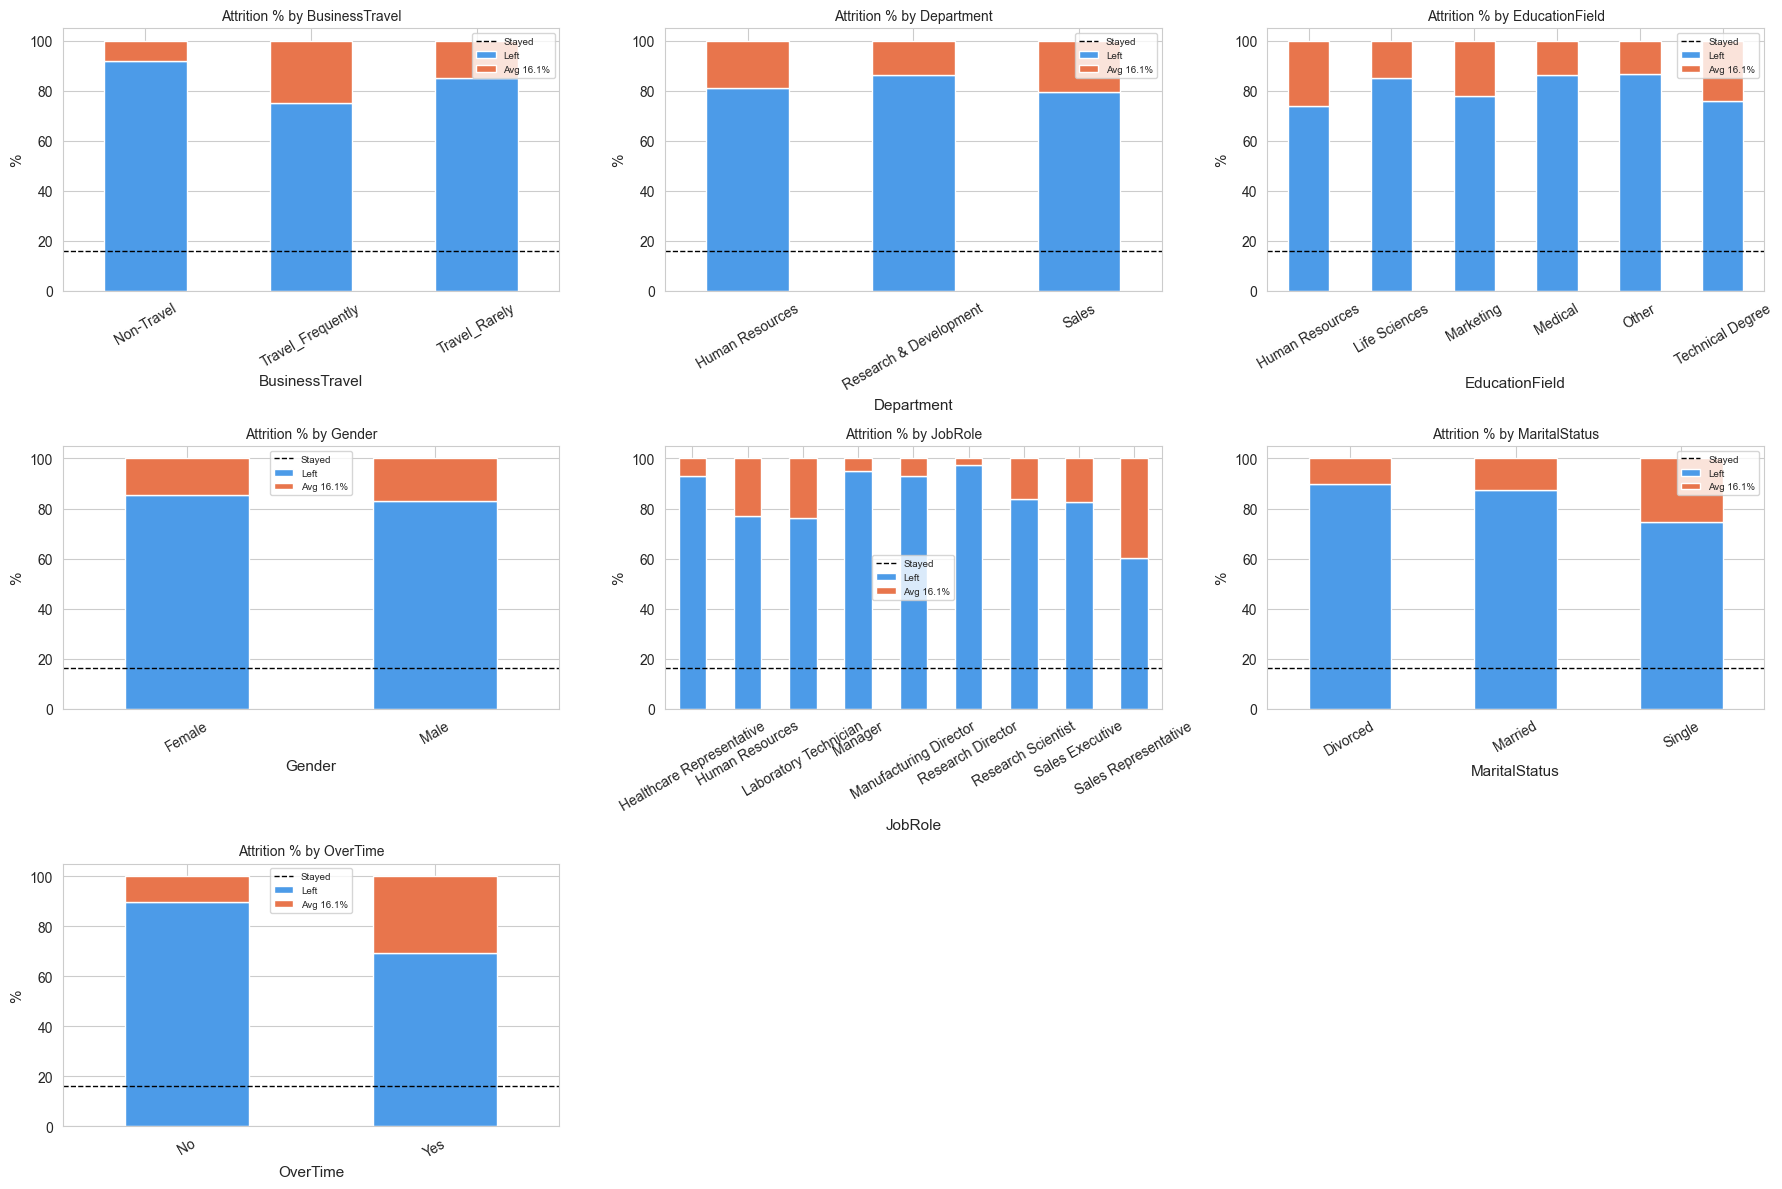

In [23]:
n_cat = len(cat_cols)
n_cat_cols = 3
n_cat_rows = (n_cat + n_cat_cols - 1) // n_cat_cols

fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(18, n_cat_rows * 4))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#4C9BE8', '#E8754C'], rot=30, legend=False)
    ax.axhline(attrition_rate, color='black', ls='--', lw=1)
    ax.set_title(f"Attrition % by {col}", fontsize=10)
    ax.set_ylabel("%")
    ax.legend(['Stayed', 'Left', f'Avg {attrition_rate:.1f}%'], fontsize=7)
for ax in axes.flat[n_cat:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("results/eda_bivariate_cat.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.2.4 Targeted group analysis

In [24]:
role_attrition = (
    df.groupby('JobRole')[TARGET_COL]
      .agg(['count', 'mean'])
      .rename(columns={'mean': 'attrition_rate'})
      .sort_values('attrition_rate', ascending=False)
)
role_attrition['attrition_rate'] = (role_attrition['attrition_rate']*100).round(2)
role_attrition

,count,attrition_rate
JobRole,,
Sales Representative,83,39.76
Laboratory Technician,259,23.94
Human Resources,52,23.08
Sales Executive,326,17.48
Research Scientist,292,16.10
Manufacturing Director,145,6.90
Healthcare Representative,131,6.87
Manager,102,4.90
Research Director,80,2.50


In [25]:
ot_attrition = df.groupby('OverTime')[TARGET_COL].mean() * 100
ot_multiplier = ot_attrition['Yes']/ot_attrition['No']

pd.DataFrame({
    'OverTime': ['No', 'Yes'],
    'attrition_rate': [round(ot_attrition['No'], 2), round(ot_attrition['Yes'], 2)],
    'multiplier': ['1.00x (baseline)', f'{ot_multiplier:.2f}x']
})

,OverTime,attrition_rate,multiplier
0,No,10.44,1.00x (baseline)
1,Yes,30.53,2.93x


### 2.2.5 Multivariate analysis: Correlation Matrix

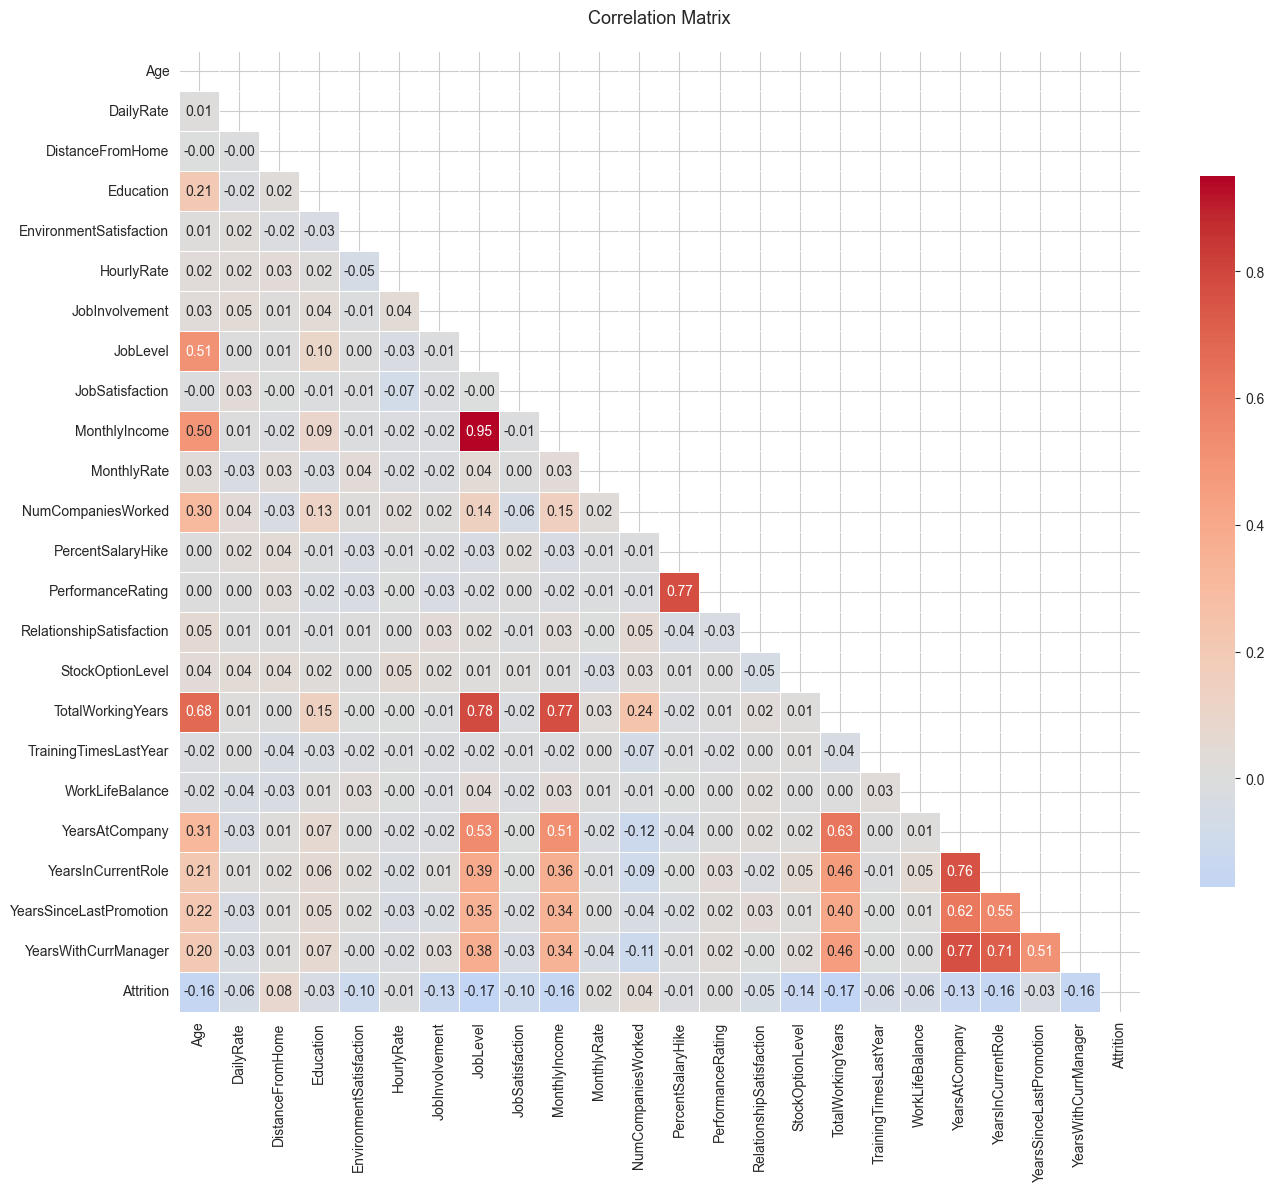

In [26]:
corr = df[num_cols + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.savefig("results/correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
target_corr = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
target_corr.head(10).round(4).to_frame('|correlation|')

,|correlation|
TotalWorkingYears,0.1711
JobLevel,0.1691
YearsInCurrentRole,0.1605
MonthlyIncome,0.1598
Age,0.1592
YearsWithCurrManager,0.1562
StockOptionLevel,0.1371
YearsAtCompany,0.1344
JobInvolvement,0.1300
JobSatisfaction,0.1035


## 2.3 Inferential statistics

### 2.3.1 Normality tests

In [28]:
norm_results = []
for col in num_cols:
    sample = df[col].sample(min(len(df), 5000), random_state=RANDOM_STATE)
    stat, p = stats.shapiro(sample)
    norm_results.append({
        'feature':   col,
        'statistic': round(stat, 4),
        'p_value':   round(p, 4),
        'is_normal': p > 0.05
    })

norm_df = pd.DataFrame(norm_results)
normal_cols     = norm_df[norm_df['is_normal']]['feature'].tolist()
non_normal_cols = norm_df[~norm_df['is_normal']]['feature'].tolist()
norm_df

,feature,statistic,p_value,is_normal
0,Age,0.9774,0.0,False
1,DailyRate,0.9544,0.0,False
2,DistanceFromHome,0.8616,0.0,False
3,Education,0.8954,0.0,False
4,EnvironmentSatisfaction,0.8490,0.0,False
5,HourlyRate,0.9550,0.0,False
6,JobInvolvement,0.8094,0.0,False
7,JobLevel,0.8220,0.0,False
8,JobSatisfaction,0.8456,0.0,False
9,MonthlyIncome,0.8279,0.0,False


### 2.3.2 Group difference tests: Numerical Features

In [29]:
group_test_results = []
stayed_df = df[df[TARGET_COL] == 0]
left_df   = df[df[TARGET_COL] == 1]

for col in num_cols:
    g0, g1 = stayed_df[col], left_df[col]

    if col in normal_cols:
        _, lev_p = stats.levene(g0, g1)
        equal_var = lev_p > 0.05
        stat, p = stats.ttest_ind(g0, g1, equal_var=equal_var)
        test_name = "Welch t-test" if not equal_var else "t-test"
    else:
        stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        test_name = "Mann-Whitney U"

    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2)/2)
    cohen_d = abs(g0.mean() - g1.mean())/pooled_std if pooled_std > 0 else 0

    if cohen_d < 0.2:
        effect = 'Negligible'
    elif cohen_d < 0.5:
        effect = 'Small'
    elif cohen_d < 0.8:
        effect = 'Medium'
    else:
        effect = 'Large'

    group_test_results.append({
        'feature':     col,
        'test':        test_name,
        'mean_stayed': round(g0.mean(), 3),
        'mean_left':   round(g1.mean(), 3),
        'p_value':     round(p, 4),
        'significant': p < 0.05,
        'cohen_d':     round(cohen_d, 3),
        'effect':      effect
    })

num_test_df = pd.DataFrame(group_test_results).sort_values('p_value')
num_test_df

,feature,test,mean_stayed,mean_left,p_value,significant,cohen_d,effect
0,Age,Mann-Whitney U,37.561,33.608,0.0000,True,0.425,Small
7,JobLevel,Mann-Whitney U,2.146,1.637,0.0000,True,0.493,Small
6,JobInvolvement,Mann-Whitney U,2.770,2.519,0.0000,True,0.343,Small
9,MonthlyIncome,Mann-Whitney U,6832.740,4787.093,0.0000,True,0.479,Small
15,StockOptionLevel,Mann-Whitney U,0.845,0.527,0.0000,True,0.374,Small
22,YearsWithCurrManager,Mann-Whitney U,4.367,2.852,0.0000,True,0.449,Small
19,YearsAtCompany,Mann-Whitney U,7.369,5.131,0.0000,True,0.372,Small
16,TotalWorkingYears,Mann-Whitney U,11.863,8.245,0.0000,True,0.484,Small
20,YearsInCurrentRole,Mann-Whitney U,4.484,2.903,0.0000,True,0.462,Small
8,JobSatisfaction,Mann-Whitney U,2.779,2.468,0.0001,True,0.281,Small


In [30]:
num_test_df.to_csv("results/inferential_numerical.csv", index=False)

### 2.3.3 Independence tests: Categorical features

In [31]:
chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET_COL])
    chi2_stat, p, dof, _ = stats.chi2_contingency(ct)

    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2_stat/(n*min_dim)) if min_dim>0 else 0

    if cramers_v < 0.1:
        effect = 'Negligible'
    elif cramers_v < 0.3:
        effect = 'Small'
    elif cramers_v < 0.5:
        effect = 'Medium'
    else:
        effect = 'Large'

    chi2_results.append({
        'feature':     col,
        'chi2':        round(chi2_stat, 2),
        'dof':         dof,
        'p_value':     round(p, 4),
        'significant': p < 0.05,
        'cramers_v':   round(cramers_v, 3),
        'effect':      effect
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df

,feature,chi2,dof,p_value,significant,cramers_v,effect
0,BusinessTravel,24.18,2,0.0000,True,0.128,Small
6,OverTime,87.56,1,0.0000,True,0.244,Small
5,MaritalStatus,46.16,2,0.0000,True,0.177,Small
4,JobRole,86.19,8,0.0000,True,0.242,Small
1,Department,10.80,2,0.0045,True,0.086,Negligible
2,EducationField,16.02,5,0.0068,True,0.104,Small
3,Gender,1.12,1,0.2906,False,0.028,Negligible


In [32]:
chi2_df.to_csv("results/inferential_categorical.csv", index=False)

### 2.3.4 Inferential summary

In [33]:
sig_num_features = num_test_df[
    (num_test_df['significant']) & (num_test_df['cohen_d'] >= 0.2)
]['feature'].tolist()

sig_cat_features = chi2_df[
    (chi2_df['significant']) & (chi2_df['cramers_v'] >= 0.1)
]['feature'].tolist()

not_sig_features = (
    num_test_df[~num_test_df['significant']]['feature'].tolist() +
    chi2_df[~chi2_df['significant']]['feature'].tolist()
)

summary_inferential = pd.DataFrame({
    'category': ['Significant Numerical (effect >= Small)',
                 'Significant Categorical (effect >= Small)',
                 'Not Significant'],
    'count':    [len(sig_num_features), len(sig_cat_features), len(not_sig_features)],
    'features': [', '.join(sig_num_features),
                 ', '.join(sig_cat_features),
                 ', '.join(not_sig_features)]
})
summary_inferential

,category,count,features
0,Significant Numerical (effect >= Small),12,"Age, JobLevel, JobInvolvement, MonthlyIncome, ..."
1,Significant Categorical (effect >= Small),5,"BusinessTravel, OverTime, MaritalStatus, JobRo..."
2,Not Significant,8,"RelationshipSatisfaction, NumCompaniesWorked, ..."


# Part III. Insights & Stategy

## 3.1 Key insights from data exploration


Based on EDA and inferential statistics, ten actionable insights emerge:

**Insight 1: OverTime is the strongest single predictor**  
Employees who work overtime have an attrition rate of 30.53%, compared with 10.44% for employees who do not work overtime.

**Insight 2: Young employees are at higher risk**  
Employees aged 18 to 30 have an attrition rate of 25.91%, while employees aged 41 to 50 have an attrition rate of 10.56%.

**Insight 3: New Hires Are Vulnerable**  
Employees with less than 2 years at the company have an attrition rate of 34.88%, more than double the overall company average of 16.12%.

**Insight 4: Low income is associated with higher attrition**  
Employees in the lowest income quintile have an attrition rate of 31.29%, compared with 9.18% in the highest income quintile.

**Insight 5: Attrition risk varies strongly by job role**  
Sales Representatives have the highest attrition rate at 39.76%, while Research Directors have one of the lowest attrition rates at 2.50%.

**Insight 6: Frequent business travel is linked to higher attrition**  
Employees who travel frequently have an attrition rate of 24.91%, compared with 8.00% for employees who do not travel.

**Insight 7: Stock options appear to support retention**  
Employees with no stock options have an attrition rate of 24.41%, while employees with at least one stock option level have an attrition rate of around 9.89%.

**Insight 8: Manager tenure and stability matter**  
Employees with zero years under their current manager show a much higher attrition rate, around 32.32%, compared with 11.05% for employees with 6 or more years under their current manager.

**Insight 9: Tenure-related features contain overlapping information**  
YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager are highly correlated. TotalWorkingYears is also related to tenure and job level, but not all tenure correlations are equally strong.

**Insight 10: Class imbalance requires careful model handling**  
Only 16.12% of employees left the company, so accuracy alone can be misleading. Recall, F2, PR-AUC, threshold tuning, and top-k analysis are more appropriate for this HR use case.

## 3.2 Modeling strategy

This project compares two models with complementary strengths:

| Model | Strength | Role |
|-------|---------|------|
| **Logistic Regression** | Interpretable, stable on small data, gives probability estimates with clear coefficients | Baseline — proves whether complexity helps |
| **XGBoost** | Captures non-linear patterns and feature interactions, robust to outliers | Main model — should beat baseline if interactions matter |

### Pipeline integrity principles

| Decision | Rationale |
|----------|-----------|
| Split data BEFORE feature engineering | Prevent all forms of leakage |
| Compute quantile thresholds only on train | Avoid global statistics leakage |
| No SMOTE: use `class_weight` / `scale_pos_weight` | More stable than SMOTE for small datasets |
| Reduced XGBoost complexity (max_depth=3) | 1029 train samples insufficient for deep trees |
| CV-based threshold tuning | Validation set (220 samples) too small for reliable tuning |
| Feature count ≤ n_train/30 | ~34 features max for 1029 train samples |

# Part IV. Model implementation



## 4.1 Data splitting

In [34]:
X_base = df.drop(columns=[TARGET_COL])
y_base = df[TARGET_COL]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_base, y_base, test_size=0.15,
    random_state=RANDOM_STATE, stratify=y_base
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176,
    random_state=RANDOM_STATE, stratify=y_temp
)

split_summary = pd.DataFrame({
    'set': ['Train', 'Validation', 'Test'],
    'n_samples': [len(X_train), len(X_val), len(X_test)],
    'pct': [round(len(X_train)/len(X_base)*100, 1),
           round(len(X_val)/len(X_base)*100, 1),
           round(len(X_test)/len(X_base)*100, 1)],
    'attrition_rate': [round(y_train.mean()*100, 2),
                       round(y_val.mean()*100, 2),
                       round(y_test.mean()*100, 2)]
})
split_summary

,set,n_samples,pct,attrition_rate
0,Train,1029,70.0,16.13
1,Validation,220,15.0,15.91
2,Test,221,15.0,16.29


## 4.2 Feature engineering

### 4.2.1 Categorical encoding

In [35]:
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}

def encode_features(X):
    X = X.copy()
    X['BusinessTravel'] = X['BusinessTravel'].map(travel_map)
    X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})
    X['OverTime'] = X['OverTime'].map({'No': 0, 'Yes': 1})
    nominal = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
    X = pd.get_dummies(X, columns=nominal, drop_first=True, dtype=int)
    return X

X_train_enc = encode_features(X_train)
X_val_enc = encode_features(X_val)
X_test_enc = encode_features(X_test)

all_cols = sorted(set(X_train_enc.columns)|set(X_val_enc.columns)|set(X_test_enc.columns))
X_train_enc = X_train_enc.reindex(columns=all_cols, fill_value=0)
X_val_enc = X_val_enc.reindex(columns=all_cols, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=all_cols, fill_value=0)

X_train_enc.shape, X_val_enc.shape, X_test_enc.shape

((1029, 43), (220, 43), (221, 43))

### 4.2.2 Binary risk indicator

In [36]:
income_q25_train = X_train_enc['MonthlyIncome'].quantile(0.25)

def add_binary_features(X, income_threshold):
    X = X.copy()
    X['IsYoung'] = (X['Age'] < 30).astype(int)
    X['IsNewHire'] = (X['YearsAtCompany'] < 2).astype(int)
    X['HasStockOption'] = (X['StockOptionLevel'] > 0).astype(int)
    X['IsLowIncome'] = (X['MonthlyIncome'] < income_threshold).astype(int)
    if 'MaritalStatus_Single' in X.columns:
        X['IsSingle'] = X['MaritalStatus_Single'].copy()
    else:
        X['IsSingle'] = 0
    return X

X_train_enc = add_binary_features(X_train_enc, income_q25_train)
X_val_enc = add_binary_features(X_val_enc, income_q25_train)
X_test_enc = add_binary_features(X_test_enc, income_q25_train)

pd.DataFrame({
    'feature': ['IsYoung', 'IsNewHire', 'HasStockOption', 'IsLowIncome', 'IsSingle'],
    'train_count': [X_train_enc[c].sum() for c in ['IsYoung', 'IsNewHire', 'HasStockOption', 'IsLowIncome', 'IsSingle']]})

,feature,train_count
0,IsYoung,226
1,IsNewHire,148
2,HasStockOption,594
3,IsLowIncome,257
4,IsSingle,322


### 4.2.3 Interaction features

In [37]:
def add_interaction_features(X):
    X = X.copy()
    X['OT_LowJobSat'] = ((X['OverTime'] == 1)&(X['JobSatisfaction']<= 2)).astype(int)
    X['OT_LowEnvSat'] = ((X['OverTime'] == 1)&(X['EnvironmentSatisfaction']<= 2)).astype(int)
    X['OT_LowWLB'] = ((X['OverTime'] == 1) & (X['WorkLifeBalance'] <= 2)).astype(int)
    X['ManagerStability'] = X['YearsWithCurrManager']/(X['YearsAtCompany'] + 1)
    X['PromotionGap'] = X['YearsSinceLastPromotion']/(X['YearsAtCompany'] + 1)
    X['IncomePerYear'] = X['MonthlyIncome']/(X['TotalWorkingYears'] + 1)
    return X

X_train_enc = add_interaction_features(X_train_enc)
X_val_enc   = add_interaction_features(X_val_enc)
X_test_enc  = add_interaction_features(X_test_enc)

X_train_enc[['OT_LowJobSat', 'OT_LowEnvSat', 'OT_LowWLB',
             'ManagerStability', 'PromotionGap', 'IncomePerYear']].describe().round(3)

,OT_LowJobSat,OT_LowEnvSat,OT_LowWLB,ManagerStability,PromotionGap,IncomePerYear
count,1029.000,1029.000,1029.000,1029.000,1029.000,1029.000
mean,0.105,0.092,0.082,0.472,0.238,582.164
std,0.307,0.290,0.274,0.278,0.273,284.091
min,0.000,0.000,0.000,0.000,0.000,95.286
25%,0.000,0.000,0.000,0.300,0.000,373.875
50%,0.000,0.000,0.000,0.500,0.143,546.864
75%,0.000,0.000,0.000,0.667,0.455,731.435
max,1.000,1.000,1.000,0.895,0.917,1904.000


### 4.2.4 Log transformations

In [38]:
skewed_features = ['MonthlyIncome', 'NumCompaniesWorked',
                    'YearsSinceLastPromotion', 'DistanceFromHome', 'YearsAtCompany']

for col in skewed_features:
    X_train_enc[f'{col}_log'] = np.log1p(X_train_enc[col])
    X_val_enc[f'{col}_log']   = np.log1p(X_val_enc[col])
    X_test_enc[f'{col}_log']  = np.log1p(X_test_enc[col])

X_train_enc.shape

(1029, 59)

## 4.3 Feature selection

In [39]:
core_numerical = [
    'OverTime', 'MonthlyIncome', 'Age', 'TotalWorkingYears',
    'JobLevel', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsWithCurrManager', 'StockOptionLevel',
    'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'BusinessTravel', 'DistanceFromHome',
    'WorkLifeBalance', 'YearsSinceLastPromotion', 'TrainingTimesLastYear'
]

engineered_features = [
    'OT_LowJobSat', 'OT_LowEnvSat', 'OT_LowWLB',
    'HasStockOption', 'IsNewHire', 'IsYoung', 'IsLowIncome',
    'ManagerStability', 'PromotionGap', 'MonthlyIncome_log'
]

jobrole_cols  = [c for c in X_train_enc.columns if c.startswith('JobRole_')]
marital_cols  = [c for c in X_train_enc.columns if c.startswith('MaritalStatus_')]
dept_cols = [c for c in X_train_enc.columns if c.startswith('Department_')]
edfield_cols  = [c for c in X_train_enc.columns if c.startswith('EducationField_')]

final_features = (
    [c for c in core_numerical     if c in X_train_enc.columns] +
    [c for c in engineered_features if c in X_train_enc.columns] +
    jobrole_cols + marital_cols + dept_cols + edfield_cols
)
final_features = list(dict.fromkeys(final_features))

xgb_core = [
    'OverTime', 'MonthlyIncome', 'Age', 'TotalWorkingYears',
    'JobLevel', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsWithCurrManager', 'StockOptionLevel',
    'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'BusinessTravel', 'DistanceFromHome',
    'WorkLifeBalance', 'YearsSinceLastPromotion'
]

xgb_features = (
    [c for c in xgb_core if c in X_train_enc.columns] +
    [c for c in engineered_features if c in X_train_enc.columns] +
    jobrole_cols + marital_cols + edfield_cols
)
xgb_features = list(dict.fromkeys(xgb_features))

pd.DataFrame({
    'set': ['LR (final_features)', 'XGB (xgb_features)'],
    'n_features': [len(final_features), len(xgb_features)],
    'note': ['includes Dept + Training', 'no Dept, no Training']
})

,set,n_features,note
0,LR (final_features),44,includes Dept + Training
1,XGB (xgb_features),41,"no Dept, no Training"


In [40]:
X_train_final = X_train_enc[final_features]
X_val_final = X_val_enc[final_features]
X_test_final = X_test_enc[final_features]

X_train_xgb = X_train_enc[xgb_features]
X_val_xgb = X_val_enc[xgb_features]
X_test_xgb = X_test_enc[xgb_features]

n_train = len(X_train_final)
pd.DataFrame({
    'set': ['LR features', 'XGB features'],
    'n_features': [len(final_features), len(xgb_features)],
    'sample_feat_ratio': [round(n_train/len(final_features), 1),
                          round(n_train/len(xgb_features), 1)]})

,set,n_features,sample_feat_ratio
0,LR features,44,23.4
1,XGB features,41,25.1


## 4.4 Imbalance handling

In [41]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metrics = ['f1', 'roc_auc', 'recall', 'precision', 'average_precision']

## 4.5 Cross-Validation setup

In [42]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
natural_spw = neg_count / pos_count

spw_candidates = [3.0, natural_spw, 7.0, 10.0, 12.0]
spw_cv_results = []

for spw in spw_candidates:
    xgb_probe = XGBClassifier(
        n_estimators=300, max_depth=2, learning_rate=0.03,
        min_child_weight=10, gamma=1, subsample=0.7,
        colsample_bytree=0.6, reg_alpha=1, reg_lambda=10,
        max_delta_step=1, scale_pos_weight=spw,
        random_state=RANDOM_STATE, eval_metric='aucpr', verbosity=0
    )
    scores = cross_validate(
        xgb_probe, X_train_final if 'X_train_final' in dir() else X_train_enc,
        y_train, cv=cv_strat,
        scoring=['recall', 'f1', 'average_precision'],
        n_jobs=-1
    )
    spw_cv_results.append({
        'scale_pos_weight': round(spw, 2),
        'cv_recall': round(scores['test_recall'].mean(), 4),
        'cv_f1': round(scores['test_f1'].mean(), 4),
        'cv_pr_auc': round(scores['test_average_precision'].mean(), 4),
        'recall_std': round(scores['test_recall'].std(), 4)
    })

spw_df = pd.DataFrame(spw_cv_results)

best_spw_row = spw_df.loc[spw_df['cv_f1'].idxmax()]
scale_pos_weight = best_spw_row['scale_pos_weight']

spw_df['selected'] = spw_df['scale_pos_weight'] == scale_pos_weight
spw_df

,scale_pos_weight,cv_recall,cv_f1,cv_pr_auc,recall_std,selected
0,3.0,0.5601,0.5594,0.5979,0.0689,True
1,5.2,0.6922,0.5332,0.6028,0.0859,False
2,7.0,0.7465,0.5037,0.5972,0.0637,False
3,10.0,0.7827,0.4344,0.5893,0.0684,False
4,12.0,0.8189,0.4094,0.5874,0.0643,False


### 4.5 XGBoost Hyperparameter Search: Optimizing F2 Score

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    random_state=RANDOM_STATE,
    eval_metric='aucpr',
    verbosity=0
)

param_distributions = {
    'max_depth':         [1, 2],
    'min_child_weight':  [10, 15, 20, 30],
    'gamma':             [1, 2, 3, 5],
    'reg_alpha':         [1, 2, 5, 10],
    'reg_lambda':        [10, 15, 20, 30],
    'subsample':         [0.55, 0.65, 0.75],
    'colsample_bytree':  [0.45, 0.55, 0.65],
    'scale_pos_weight':  [
        scale_pos_weight,
        round(scale_pos_weight * 1.3, 2),
        round(scale_pos_weight * 1.6, 2),
        round(scale_pos_weight * 2.0, 2)
    ],
    'max_delta_step': [1, 2, 3]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=80,
    scoring=f2_scorer,
    cv=cv_strat,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
    refit=True
)

xgb_search.fit(X_train_xgb, y_train)

pd.Series({
    'best_cv_f2': round(xgb_search.best_score_, 4),
    **xgb_search.best_params_
}).to_frame('xgb_search_results')

,xgb_search_results
best_cv_f2,0.6043
subsample,0.5500
scale_pos_weight,6.0000
reg_lambda,10.0000
reg_alpha,10.0000
min_child_weight,30.0000
max_depth,1.0000
max_delta_step,2.0000
gamma,2.0000
colsample_bytree,0.4500


## 4.6 Baseline Model: Logistic Regression

In [44]:
pipeline_lr = ImbPipeline([
    ('scaler', RobustScaler()),
    ('clf', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=1.0,
        random_state=RANDOM_STATE
    ))
])

lr_cv = cross_validate(
    pipeline_lr, X_train_final, y_train, cv=cv_strat,
    scoring=scoring_metrics, return_train_score=True, n_jobs=-1
)

lr_cv_summary = pd.DataFrame({
    'metric': scoring_metrics,
    'train': [round(lr_cv[f'train_{m}'].mean(), 4) for m in scoring_metrics],
    'val_mean': [round(lr_cv[f'test_{m}'].mean(), 4)  for m in scoring_metrics],
    'val_std': [round(lr_cv[f'test_{m}'].std(), 4)   for m in scoring_metrics]
})
lr_cv_summary['gap'] = (lr_cv_summary['train'] - lr_cv_summary['val_mean']).round(4)
lr_cv_summary

,metric,train,val_mean,val_std,gap
0,f1,0.5612,0.4947,0.0147,0.0665
1,roc_auc,0.8795,0.8152,0.0234,0.0643
2,recall,0.7922,0.6927,0.0234,0.0995
3,precision,0.4347,0.3850,0.0149,0.0497
4,average_precision,0.7036,0.6206,0.0792,0.0830


In [45]:
pipeline_lr.fit(X_train_final, y_train)
lr_val_prob = pipeline_lr.predict_proba(X_val_final)[:, 1]
lr_val_pred = pipeline_lr.predict(X_val_final)

lr_val_metrics = {
    'accuracy':  round((lr_val_pred == y_val).mean(), 4),
    'precision': round(precision_score(y_val, lr_val_pred), 4),
    'recall':    round(recall_score(y_val, lr_val_pred), 4),
    'f1':        round(f1_score(y_val, lr_val_pred), 4),
    'roc_auc':   round(roc_auc_score(y_val, lr_val_prob), 4),
    'pr_auc':    round(average_precision_score(y_val, lr_val_prob), 4)
}
pd.Series(lr_val_metrics, name='LR_Validation').to_frame()

,LR_Validation
accuracy,0.7545
precision,0.3699
recall,0.7714
f1,0.5000
roc_auc,0.8170
pr_auc,0.5782


## 4.7 Main Model: XGBoost

In [46]:
xgb_model = xgb_search.best_estimator_

xgb_cv = cross_validate(
    xgb_model, X_train_xgb, y_train, cv=cv_strat,
    scoring=scoring_metrics, return_train_score=True, n_jobs=-1
)

xgb_cv_summary = pd.DataFrame({
    'metric': scoring_metrics,
    'train': [round(xgb_cv[f'train_{m}'].mean(), 4) for m in scoring_metrics],
    'val_mean': [round(xgb_cv[f'test_{m}'].mean(), 4)  for m in scoring_metrics],
    'val_std': [round(xgb_cv[f'test_{m}'].std(), 4)   for m in scoring_metrics]
})
xgb_cv_summary['gap'] = (xgb_cv_summary['train'] - xgb_cv_summary['val_mean']).round(4)
xgb_cv_summary

,metric,train,val_mean,val_std,gap
0,f1,0.4996,0.4671,0.0273,0.0325
1,roc_auc,0.8386,0.7886,0.0349,0.0500
2,recall,0.8057,0.7529,0.0405,0.0528
3,precision,0.3622,0.3394,0.0270,0.0228
4,average_precision,0.6214,0.5588,0.0935,0.0626


In [47]:
xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

xgb_val_prob = xgb_model.predict_proba(X_val_xgb)[:, 1]
xgb_val_pred = xgb_model.predict(X_val_xgb)

xgb_val_metrics = {
    'accuracy':  round((xgb_val_pred == y_val).mean(), 4),
    'precision': round(precision_score(y_val, xgb_val_pred), 4),
    'recall':    round(recall_score(y_val, xgb_val_pred), 4),
    'f1':        round(f1_score(y_val, xgb_val_pred), 4),
    'roc_auc':   round(roc_auc_score(y_val, xgb_val_prob), 4),
    'pr_auc':    round(average_precision_score(y_val, xgb_val_prob), 4)
}
pd.Series(xgb_val_metrics, name='XGB_Validation').to_frame()

,XGB_Validation
accuracy,0.6773
precision,0.2805
recall,0.6571
f1,0.3932
roc_auc,0.7700
pr_auc,0.5654


## 4.8 CV gap analysis - Overfitting check





In [48]:
gap_analysis = pd.DataFrame({
    'model':     ['Logistic Regression', 'XGBoost'],
    'cv_train_f1': [
        round(lr_cv['train_f1'].mean(), 4),
        round(xgb_cv['train_f1'].mean(), 4)
    ],
    'cv_val_f1': [
        round(lr_cv['test_f1'].mean(), 4),
        round(xgb_cv['test_f1'].mean(), 4)
    ],
})
gap_analysis['gap']     = (gap_analysis['cv_train_f1'] - gap_analysis['cv_val_f1']).round(4)
gap_analysis['verdict'] = gap_analysis['gap'].apply(
    lambda x: 'Healthy (< 0.10)' if x < 0.10 else 'Possible overfit (>= 0.10)'
)
gap_analysis

,model,cv_train_f1,cv_val_f1,gap,verdict
0,Logistic Regression,0.5612,0.4947,0.0665,Healthy (< 0.10)
1,XGBoost,0.4996,0.4671,0.0325,Healthy (< 0.10)


## 4.9 Validation metrics comparison


In [49]:
val_comparison = pd.DataFrame([
    {**{'model': 'Logistic Regression'}, **lr_val_metrics},
    {**{'model': 'XGBoost'}, **xgb_val_metrics}
]).set_index('model')
val_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.7545,0.3699,0.7714,0.5000,0.817,0.5782
XGBoost,0.6773,0.2805,0.6571,0.3932,0.770,0.5654


In [50]:
from sklearn.metrics import accuracy_score, fbeta_score

def threshold_search(y_true, prob, model_name):
    thresholds = np.arange(0.10, 0.71, 0.02)
    rows = []

    for t in thresholds:
        pred = (prob >= t).astype(int)
        rows.append({
            'model': model_name,
            'threshold': round(t, 2),
            'accuracy': round(accuracy_score(y_true, pred), 4),
            'precision': round(precision_score(y_true, pred, zero_division=0), 4),
            'recall': round(recall_score(y_true, pred, zero_division=0), 4),
            'f1': round(f1_score(y_true, pred, zero_division=0), 4),
            'f2': round(fbeta_score(y_true, pred, beta=2, zero_division=0), 4),
            'roc_auc': round(roc_auc_score(y_true, prob), 4)
        })

    return pd.DataFrame(rows)

lr_threshold_df = threshold_search(y_val, lr_val_prob, "Logistic Regression")
xgb_threshold_df = threshold_search(y_val, xgb_val_prob, "XGBoost")

threshold_all = pd.concat([lr_threshold_df, xgb_threshold_df], ignore_index=True)
threshold_all

,model,threshold,accuracy,precision,recall,f1,f2,roc_auc
0,Logistic Regression,0.10,0.3045,0.1793,0.9429,0.3014,0.5093,0.817
1,Logistic Regression,0.12,0.3500,0.1897,0.9429,0.3158,0.5255,0.817
2,Logistic Regression,0.14,0.3909,0.2000,0.9429,0.3300,0.5410,0.817
3,Logistic Regression,0.16,0.4136,0.2062,0.9429,0.3385,0.5500,0.817
4,Logistic Regression,0.18,0.4409,0.2105,0.9143,0.3422,0.5479,0.817
...,...,...,...,...,...,...,...,...
57,XGBoost,0.62,0.8227,0.4565,0.6000,0.5185,0.5645,0.770
58,XGBoost,0.64,0.8318,0.4762,0.5714,0.5195,0.5495,0.770
59,XGBoost,0.66,0.8545,0.5429,0.5429,0.5429,0.5429,0.770
60,XGBoost,0.68,0.8682,0.6000,0.5143,0.5538,0.5294,0.770


In [51]:
def choose_threshold(threshold_df, min_precision=0.35, min_recall=0.75):
    candidates = threshold_df[
        (threshold_df['precision'] >= min_precision) &
        (threshold_df['recall'] >= min_recall)
    ]

    if len(candidates) > 0:
        return candidates.sort_values('f2', ascending=False).iloc[0]

    return threshold_df.sort_values('f2', ascending=False).iloc[0]

lr_best_threshold = choose_threshold(lr_threshold_df, min_precision=0.35, min_recall=0.75)
xgb_best_threshold = choose_threshold(xgb_threshold_df, min_precision=0.35, min_recall=0.75)

threshold_summary_both = pd.DataFrame([
    lr_best_threshold,
    xgb_best_threshold
])

threshold_summary_both

,model,threshold,accuracy,precision,recall,f1,f2,roc_auc
19,Logistic Regression,0.48,0.7409,0.3590,0.8000,0.4956,0.6422,0.817
19,XGBoost,0.48,0.6682,0.2935,0.7714,0.4252,0.5819,0.770


In [52]:
val_comparison.to_csv("results/v4_validation_comparison.csv")

## 4.10 ROC and Precision-Recall Curves

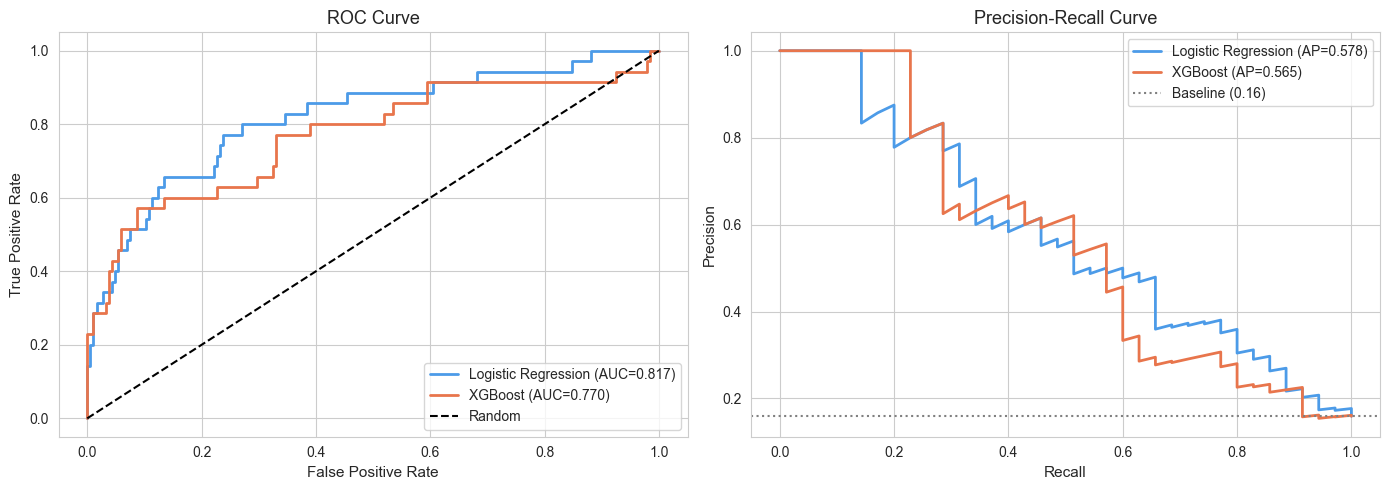

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_probs = [
    ('Logistic Regression', lr_val_prob,  '#4C9BE8'),
    ('XGBoost',             xgb_val_prob, '#E8754C')
]

for name, prob, color in model_probs:
    fpr, tpr, _ = roc_curve(y_val, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={roc_auc_score(y_val, prob):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

for name, prob, color in model_probs:
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ap = average_precision_score(y_val, prob)
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")
axes[1].axhline(y_val.mean(), color='gray', ls=':',
                label=f'Baseline ({y_val.mean():.2f})')
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/v4_roc_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.11 Model selection

In [54]:
selection_score = pd.DataFrame({
    'model': ['Logistic Regression', 'XGBoost'],
    'val_recall': [lr_val_metrics['recall'],  xgb_val_metrics['recall']],
    'val_f1': [lr_val_metrics['f1'],      xgb_val_metrics['f1']],
    'val_roc_auc': [lr_val_metrics['roc_auc'], xgb_val_metrics['roc_auc']],
    'cv_gap': gap_analysis['gap'].values
})
selection_score = selection_score.sort_values(['val_recall', 'val_roc_auc'], ascending=[False, False])
selection_score

,model,val_recall,val_f1,val_roc_auc,cv_gap
0,Logistic Regression,0.7714,0.5000,0.817,0.0665
1,XGBoost,0.6571,0.3932,0.770,0.0325


In [55]:
best_model_name = selection_score.iloc[0]['model']
model_objects = {
    'Logistic Regression': pipeline_lr,
    'XGBoost': xgb_model
}

best_model = model_objects[best_model_name]

pd.DataFrame({
    'selected_model': [best_model_name],
    'reason': [f"Highest val_recall = {selection_score.iloc[0]['val_recall']:.4f}"]})

,selected_model,reason
0,Logistic Regression,Highest val_recall = 0.7714


## 4.12 CV based threshold tuning (Multiple objectives)


In [56]:
cv_probs = cross_val_predict(
    best_model, X_train_final, y_train, cv=cv_strat,
    method='predict_proba', n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.71, 0.02)
threshold_results = []
for t in thresholds:
    preds = (cv_probs >= t).astype(int)
    threshold_results.append({
        'threshold': round(t, 2),
        'precision': round(precision_score(y_train, preds, zero_division=0), 4),
        'recall': round(recall_score(y_train, preds, zero_division=0), 4),
        'f1': round(f1_score(y_train, preds, zero_division=0), 4),
        'f2': round(fbeta_score(y_train, preds, beta=2, zero_division=0), 4),
        'f0_5': round(fbeta_score(y_train, preds, beta=0.5, zero_division=0), 4)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,f2,f0_5
0,0.10,0.2013,0.9337,0.3312,0.5404,0.2388
1,0.12,0.2049,0.9036,0.3341,0.5372,0.2424
2,0.14,0.2128,0.9036,0.3444,0.5478,0.2512
3,0.16,0.2183,0.8916,0.3507,0.5514,0.2571
4,0.18,0.2266,0.8916,0.3614,0.5619,0.2664
5,0.20,0.2344,0.8855,0.3707,0.5693,0.2749
6,0.22,0.2429,0.8795,0.3807,0.5771,0.2840
7,0.24,0.2449,0.8614,0.3813,0.5729,0.2858
8,0.26,0.2559,0.8494,0.3933,0.5802,0.2975
9,0.28,0.2598,0.8373,0.3966,0.5796,0.3014


In [57]:
threshold_best_f1 = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']
threshold_best_f2 = threshold_df.loc[threshold_df['f2'].idxmax(), 'threshold']

precision_floor = 0.30
recall_floor = 0.65
mask = (threshold_df['precision'] >= precision_floor) & (threshold_df['recall'] >= recall_floor)
if mask.any():
    threshold_high_recall = threshold_df[mask].sort_values('recall', ascending=False).iloc[0]['threshold']
else:
    threshold_high_recall = threshold_df.sort_values('recall', ascending=False).iloc[0]['threshold']

threshold_summary = pd.DataFrame({
    'strategy':  ['Max F1 (balanced)',
                  'Max F2 (recall-weighted, RECOMMENDED)',
                  f'Max Recall (precision >= {precision_floor})'],
    'threshold': [threshold_best_f1, threshold_best_f2, threshold_high_recall],
    'precision': [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'precision'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'precision'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'precision'].iloc[0]],
    'recall':    [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'recall'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'recall'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'recall'].iloc[0]],
    'f1':        [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'f1'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'f1'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'f1'].iloc[0]],
    'f2':        [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'f2'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'f2'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'f2'].iloc[0]]
})
threshold_summary

,strategy,threshold,precision,recall,f1,f2
0,Max F1 (balanced),0.70,0.5814,0.6024,0.5917,0.5981
1,"Max F2 (recall-weighted, RECOMMENDED)",0.42,0.3404,0.7711,0.4723,0.6154
2,Max Recall (precision >= 0.3),0.38,0.3099,0.7952,0.4459,0.6055


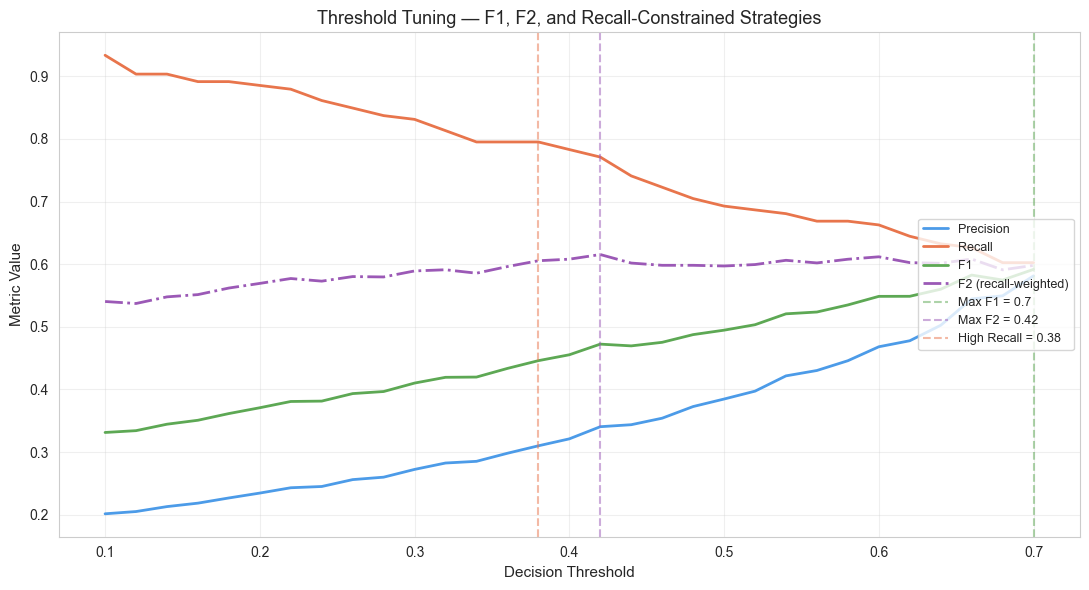

In [58]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', color='#4C9BE8', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['recall'],    label='Recall',    color='#E8754C', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['f1'],        label='F1',        color='#5DA854', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['f2'],        label='F2 (recall-weighted)',
        color='#9B59B6', lw=2, ls='-.')

ax.axvline(threshold_best_f1,     color='#5DA854', ls='--', alpha=0.5, label=f'Max F1 = {threshold_best_f1}')
ax.axvline(threshold_best_f2,     color='#9B59B6', ls='--', alpha=0.5, label=f'Max F2 = {threshold_best_f2}')
ax.axvline(threshold_high_recall, color='#E8754C', ls='--', alpha=0.5, label=f'High Recall = {threshold_high_recall}')

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric Value")
ax.set_title("Threshold Tuning — F1, F2, and Recall-Constrained Strategies")
ax.legend(loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/v4_threshold_tuning.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.13 Top k risk ranking

In [59]:
def topk_metrics(y_true, y_prob, k_pct):
    n = len(y_true)
    k = int(np.ceil(n * k_pct / 100))
    top_k_idx = np.argsort(y_prob)[::-1][:k]
    top_k_labels = np.array(y_true)[top_k_idx]

    n_caught     = int(top_k_labels.sum())
    n_total_pos  = int(np.sum(y_true))
    baseline_rate = n_total_pos / n

    precision_at_k = n_caught / k if k > 0 else 0
    recall_at_k    = n_caught / n_total_pos if n_total_pos > 0 else 0
    lift_at_k      = precision_at_k / baseline_rate if baseline_rate > 0 else 0

    return {
        'k_pct':               k_pct,
        'k_employees':         k,
        'true_leavers_caught': n_caught,
        'total_leavers':       n_total_pos,
        'precision_at_k':      round(precision_at_k, 4),
        'recall_at_k':         round(recall_at_k, 4),
        'lift_at_k':           round(lift_at_k, 2)
    }

cv_topk_results = pd.DataFrame([
    topk_metrics(y_train.values, cv_probs, k) for k in [5, 10, 15, 20, 25, 30, 40, 50]
])
cv_topk_results

,k_pct,k_employees,true_leavers_caught,total_leavers,precision_at_k,recall_at_k,lift_at_k
0,5,52,42,166,0.8077,0.2530,5.01
1,10,103,77,166,0.7476,0.4639,4.63
2,15,155,96,166,0.6194,0.5783,3.84
3,20,206,105,166,0.5097,0.6325,3.16
4,25,258,111,166,0.4302,0.6687,2.67
5,30,309,116,166,0.3754,0.6988,2.33
6,40,412,131,166,0.3180,0.7892,1.97
7,50,515,138,166,0.2680,0.8313,1.66


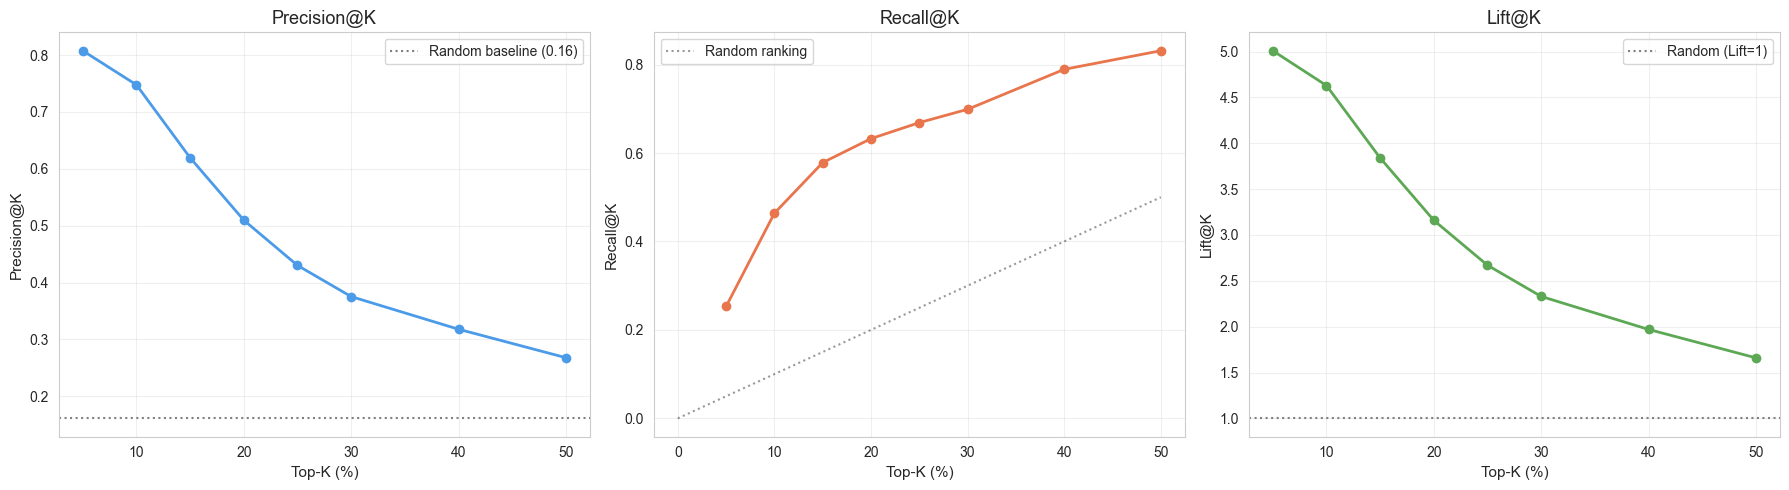

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cv_topk_results['k_pct'], cv_topk_results['precision_at_k'],
             marker='o', color='#4C9BE8', lw=2)
axes[0].axhline(y_train.mean(), color='gray', ls=':',
                label=f'Random baseline ({y_train.mean():.2f})')
axes[0].set_xlabel("Top-K (%)")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cv_topk_results['k_pct'], cv_topk_results['recall_at_k'],
             marker='o', color='#E8754C', lw=2)
axes[1].plot([0, 50], [0, 0.5], 'k:', alpha=0.4, label='Random ranking')
axes[1].set_xlabel("Top-K (%)")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(cv_topk_results['k_pct'], cv_topk_results['lift_at_k'],
             marker='o', color='#5DA854', lw=2)
axes[2].axhline(1, color='gray', ls=':', label='Random (Lift=1)')
axes[2].set_xlabel("Top-K (%)")
axes[2].set_ylabel("Lift@K")
axes[2].set_title("Lift@K")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/v4_topk_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.14 SHAP Interpretation

C:\Users\Nguyen\AppData\Local\Temp\ipykernel_36484\2346321224.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type='bar',


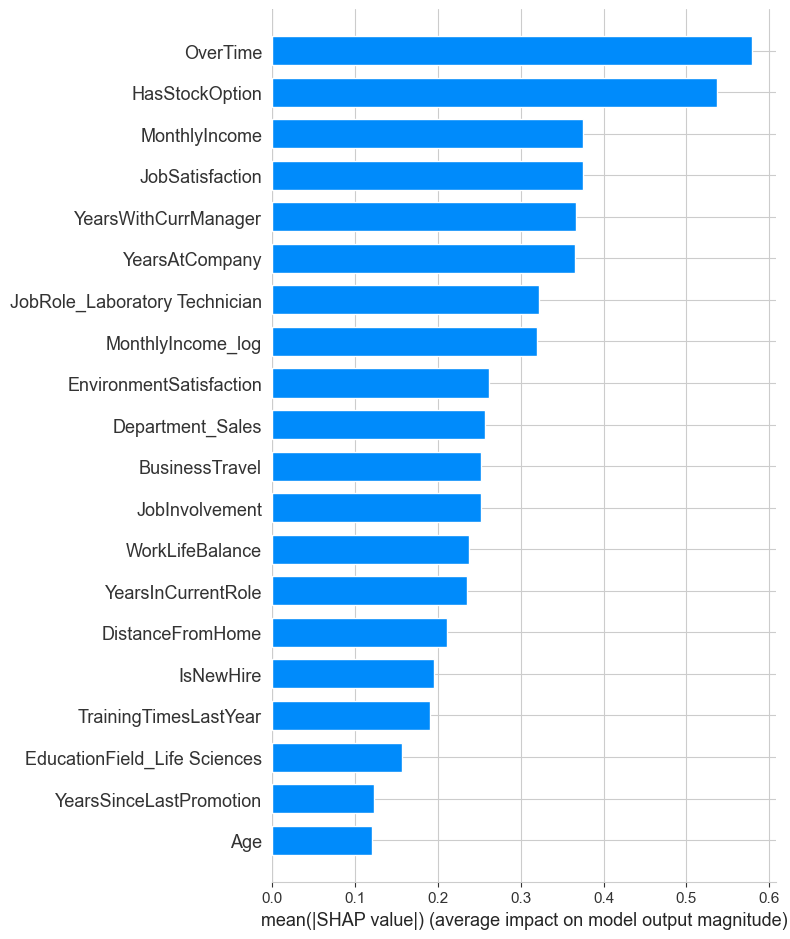

In [61]:
if best_model_name == 'XGBoost':
    shap_input = X_val_xgb
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(shap_input)
else:
    shap_input = X_val_final
    background = shap.sample(X_train_final, 100, random_state=RANDOM_STATE)
    scaler_obj = pipeline_lr.named_steps['scaler']
    clf_obj = pipeline_lr.named_steps['clf']
    explainer = shap.LinearExplainer(clf_obj, scaler_obj.transform(background))
    shap_values = explainer.shap_values(scaler_obj.transform(shap_input))

shap.summary_plot(shap_values, shap_input, plot_type='bar',
                  show=False, max_display=20)
plt.tight_layout()
plt.savefig("results/v5_shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Nguyen\AppData\Local\Temp\ipykernel_36484\2500054621.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, show=False, max_display=20)


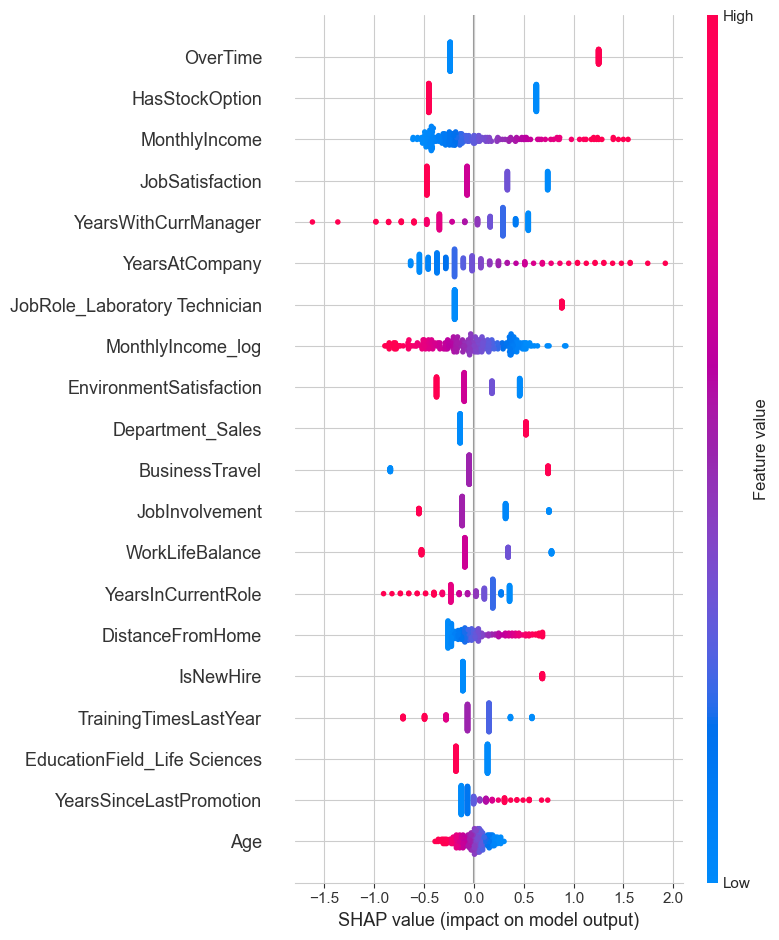

In [62]:
shap.summary_plot(shap_values, shap_input, show=False, max_display=20)
plt.tight_layout()
plt.savefig("results/v5_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.15 Final Test Evaluation

In [63]:
def eval_at_threshold(y, prob, t, label):
    pred = (prob >= t).astype(int)
    return {
        'config':    label,
        'threshold': t,
        'precision': round(precision_score(y, pred, zero_division=0), 4),
        'recall':    round(recall_score(y, pred, zero_division=0), 4),
        'f1':        round(f1_score(y, pred, zero_division=0), 4),
        'f2':        round(fbeta_score(y, pred, beta=2, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y, prob), 4)
    }

lr_test_prob  = pipeline_lr.predict_proba(X_test_final)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

if best_model_name == 'XGBoost':
    best_test_prob = xgb_test_prob
else:
    best_test_prob = lr_test_prob

best_test_pred_default = (best_test_prob >= 0.5).astype(int)
best_test_pred_f1      = (best_test_prob >= threshold_best_f1).astype(int)
best_test_pred_f2      = (best_test_prob >= threshold_best_f2).astype(int)
best_test_pred_recall  = (best_test_prob >= threshold_high_recall).astype(int)

lr_tuned_threshold  = threshold_best_f2 if best_model_name == 'Logistic Regression' else threshold_best_f1
xgb_tuned_threshold = xgb_best_threshold['threshold'] if 'xgb_best_threshold' in dir() else threshold_best_f2

test_results = pd.DataFrame([
    eval_at_threshold(y_test, lr_test_prob,  0.50,               'LR default 0.50'),
    eval_at_threshold(y_test, lr_test_prob,  lr_tuned_threshold,  f'LR tuned {lr_tuned_threshold:.2f}'),
    eval_at_threshold(y_test, xgb_test_prob, 0.50,               'XGB default 0.50'),
    eval_at_threshold(y_test, xgb_test_prob, xgb_tuned_threshold, f'XGB tuned {xgb_tuned_threshold:.2f}')
])
test_results

,config,threshold,precision,recall,f1,f2,roc_auc
0,LR default 0.50,0.50,0.4426,0.7500,0.5567,0.6585,0.8647
1,LR tuned 0.42,0.42,0.3580,0.8056,0.4957,0.6444,0.8647
2,XGB default 0.50,0.50,0.3647,0.8611,0.5124,0.6769,0.8225
3,XGB tuned 0.48,0.48,0.3523,0.8611,0.5000,0.6681,0.8225


In [64]:
test_results.to_csv("results/v4_final_test_results.csv", index=False)

### 4.15.1 Top-K Risk Ranking: Test Set Validation

In [65]:
test_topk_results = pd.DataFrame([
    topk_metrics(y_test.values, best_test_prob, k) for k in [5, 10, 15, 20, 25, 30, 40, 50]
])
test_topk_results

,k_pct,k_employees,true_leavers_caught,total_leavers,precision_at_k,recall_at_k,lift_at_k
0,5,12,11,36,0.9167,0.3056,5.63
1,10,23,14,36,0.6087,0.3889,3.74
2,15,34,20,36,0.5882,0.5556,3.61
3,20,45,21,36,0.4667,0.5833,2.86
4,25,56,24,36,0.4286,0.6667,2.63
5,30,67,27,36,0.4030,0.7500,2.47
6,40,89,30,36,0.3371,0.8333,2.07
7,50,111,35,36,0.3153,0.9722,1.94


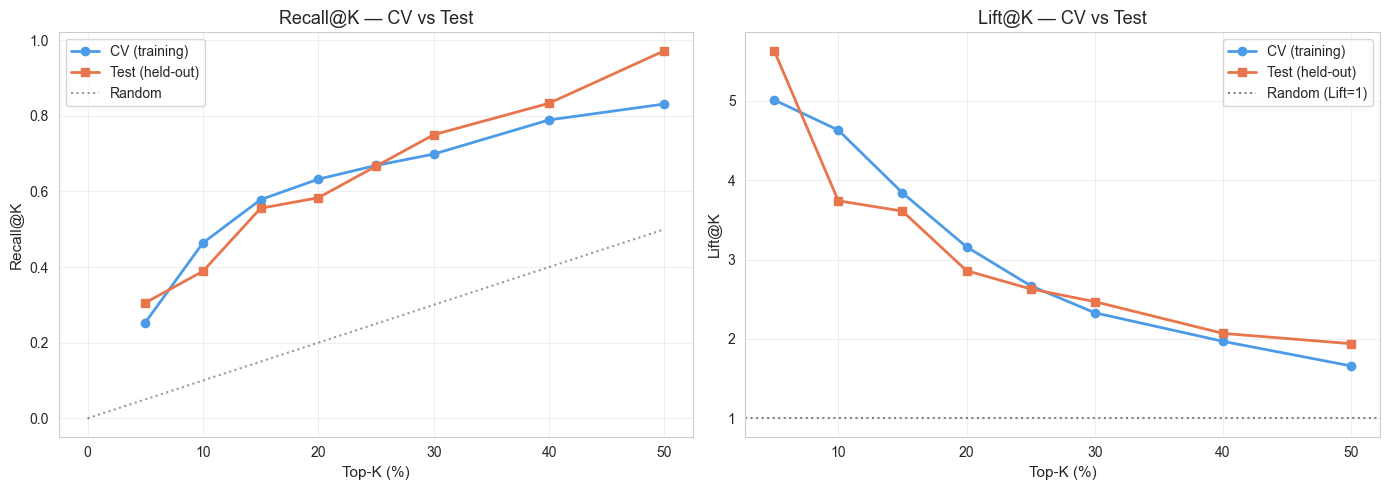

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cv_topk_results['k_pct'],  cv_topk_results['recall_at_k'],
             marker='o', color='#4C9BE8', lw=2, label='CV (training)')
axes[0].plot(test_topk_results['k_pct'], test_topk_results['recall_at_k'],
             marker='s', color='#E8754C', lw=2, label='Test (held-out)')
axes[0].plot([0, 50], [0, 0.5], 'k:', alpha=0.4, label='Random')
axes[0].set_xlabel("Top-K (%)")
axes[0].set_ylabel("Recall@K")
axes[0].set_title("Recall@K — CV vs Test")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cv_topk_results['k_pct'],  cv_topk_results['lift_at_k'],
             marker='o', color='#4C9BE8', lw=2, label='CV (training)')
axes[1].plot(test_topk_results['k_pct'], test_topk_results['lift_at_k'],
             marker='s', color='#E8754C', lw=2, label='Test (held-out)')
axes[1].axhline(1, color='gray', ls=':', label='Random (Lift=1)')
axes[1].set_xlabel("Top-K (%)")
axes[1].set_ylabel("Lift@K")
axes[1].set_title("Lift@K — CV vs Test")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/v4_topk_test_validation.png", dpi=150, bbox_inches='tight')
plt.show()

In [67]:
test_topk_results.to_csv("results/v4_topk_test_results.csv", index=False)

### 4.15.2 Test Set Confusion Matrices: Three Operating Points

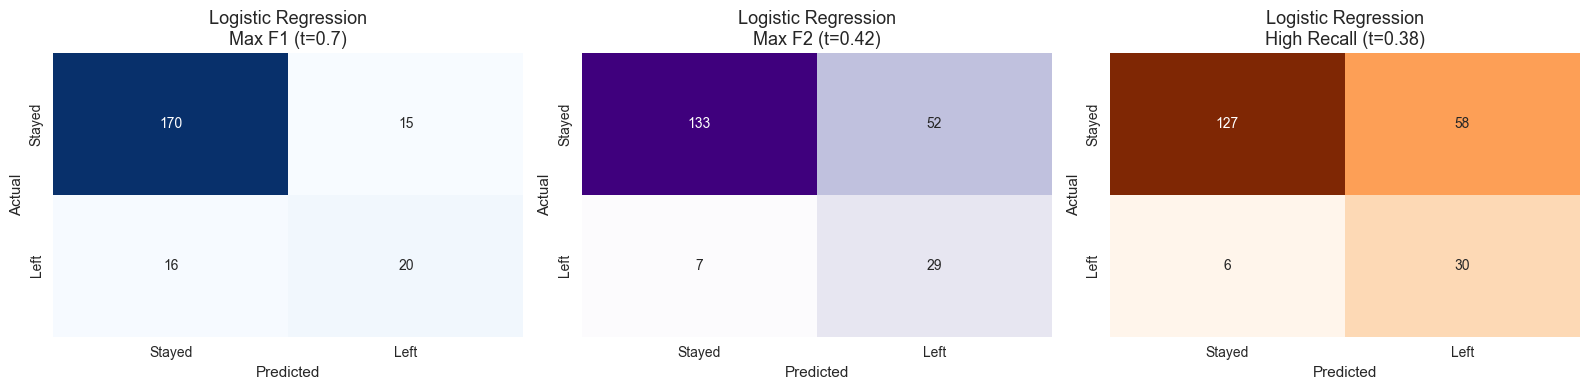

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_configs = [
    (best_test_pred_f1,     "Max F1 (t=" + str(threshold_best_f1) + ")",         'Blues'),
    (best_test_pred_f2,     "Max F2 (t=" + str(threshold_best_f2) + ")",         'Purples'),
    (best_test_pred_recall, "High Recall (t=" + str(threshold_high_recall) + ")", 'Oranges')
]

for ax, (pred, title, cmap) in zip(axes, cm_configs):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d',
                cmap=cmap, ax=ax, cbar=False,
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    ax.set_title(best_model_name + "\n" + title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("results/v4_test_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.15.3 Business Impact Translation

In [69]:
def business_impact(y_true, prob, threshold, label):
    y_pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'config': label,
        'threshold': round(threshold, 2),
        'flagged_for_action': int(tp + fp),
        'true_at_risk_caught': int(tp),
        'missed_leavers': int(fn),
        'false_alarms': int(fp),
        'catch_rate_%': round(tp / (tp + fn) * 100, 1) if (tp + fn) > 0 else 0,
        'alarm_accuracy_%': round(tp / (tp + fp) * 100, 1) if (tp + fp) > 0 else 0
    }

def business_impact_from_pred(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'config': label,
        'threshold': 'top-k',
        'flagged_for_action': int(tp + fp),
        'true_at_risk_caught': int(tp),
        'missed_leavers': int(fn),
        'false_alarms': int(fp),
        'catch_rate_%': round(tp / (tp + fn) * 100, 1) if (tp + fn) > 0 else 0,
        'alarm_accuracy_%': round(tp / (tp + fp) * 100, 1) if (tp + fp) > 0 else 0
    }

def topk_business_impact(y_true, y_prob, k_pct, label):
    n = len(y_true)
    k = int(np.ceil(n * k_pct / 100))
    top_k_idx = np.argsort(y_prob)[::-1][:k]

    y_pred = np.zeros(n, dtype=int)
    y_pred[top_k_idx] = 1

    return business_impact_from_pred(y_true, y_pred, label)

business_summary = pd.DataFrame([
    business_impact(y_test, lr_test_prob, 0.50, 'LR default 0.50'),
    business_impact(y_test, lr_test_prob, lr_tuned_threshold, f'LR tuned {lr_tuned_threshold:.2f}'),

    business_impact(y_test, xgb_test_prob, 0.50, 'XGB default 0.50'),
    business_impact(y_test, xgb_test_prob, xgb_tuned_threshold, f'XGB tuned {xgb_tuned_threshold:.2f}'),

    topk_business_impact(y_test.values, lr_test_prob, 20, 'LR top 20% riskiest'),
    topk_business_impact(y_test.values, xgb_test_prob, 20, 'XGB top 20% riskiest')
])

business_summary


,config,threshold,flagged_for_action,true_at_risk_caught,missed_leavers,false_alarms,catch_rate_%,alarm_accuracy_%
0,LR default 0.50,0.5,61,27,9,34,75.0,44.3
1,LR tuned 0.42,0.42,81,29,7,52,80.6,35.8
2,XGB default 0.50,0.5,85,31,5,54,86.1,36.5
3,XGB tuned 0.48,0.48,88,31,5,57,86.1,35.2
4,LR top 20% riskiest,top-k,45,21,15,24,58.3,46.7
5,XGB top 20% riskiest,top-k,45,22,14,23,61.1,48.9


In [70]:
business_summary.to_csv("results/v4_business_impact.csv", index=False)

## 4.16 Bootstrap Confidence Intervals for Test Metrics

In [71]:
def bootstrap_metric_ci(y_true, y_pred, y_prob, metric_fn, n_bootstrap=1000, ci=0.95):
    rng = np.random.RandomState(RANDOM_STATE)
    n = len(y_true)
    bootstrap_scores = []
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    y_prob_arr = np.asarray(y_prob) if y_prob is not None else None

    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true_arr[idx])) < 2:
            continue
        try:
            if y_prob_arr is not None and metric_fn.__name__ in ['roc_auc_score', 'average_precision_score']:
                score = metric_fn(y_true_arr[idx], y_prob_arr[idx])
            else:
                score = metric_fn(y_true_arr[idx], y_pred_arr[idx])
            bootstrap_scores.append(score)
        except Exception:
            continue

    bootstrap_scores = np.array(bootstrap_scores)
    lower = np.percentile(bootstrap_scores, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrap_scores, (1 + ci) / 2 * 100)
    return {
        'mean':       round(bootstrap_scores.mean(), 4),
        'std':        round(bootstrap_scores.std(), 4),
        'ci_lower':   round(lower, 4),
        'ci_upper':   round(upper, 4),
        'ci_width':   round(upper - lower, 4)
    }

bootstrap_results = []
for metric_name, metric_fn, needs_prob in [
    ('precision', precision_score,             False),
    ('recall',    recall_score,                False),
    ('f1',        f1_score,                    False),
    ('roc_auc',   roc_auc_score,               True),
    ('pr_auc',    average_precision_score,     True)
]:
    res = bootstrap_metric_ci(
        y_test, best_test_pred_f2,
        best_test_prob if needs_prob else None,
        metric_fn, n_bootstrap=1000
    )
    bootstrap_results.append({
        'metric':   metric_name,
        'estimate': res['mean'],
        '95%_CI':   f"[{res['ci_lower']}, {res['ci_upper']}]",
        'CI_width': res['ci_width'],
        'std':      res['std']
    })

bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df

,metric,estimate,95%_CI,CI_width,std
0,precision,0.3593,"[0.2571, 0.4684]",0.2112,0.0531
1,recall,0.8102,"[0.6774, 0.9286]",0.2512,0.0631
2,f1,0.4956,"[0.3838, 0.5986]",0.2148,0.0557
3,roc_auc,0.8666,"[0.805, 0.9207]",0.1157,0.0286
4,pr_auc,0.6306,"[0.473, 0.764]",0.2910,0.0746


In [72]:
bootstrap_df.to_csv("results/v4_bootstrap_ci.csv", index=False)

## 4.17 Calibration Analysis

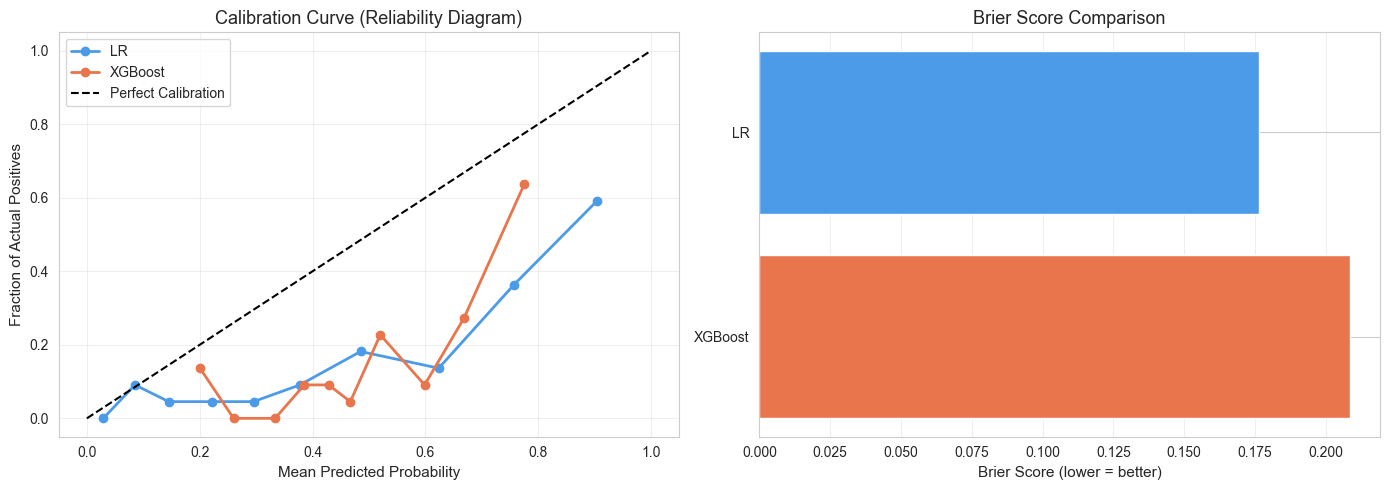

,model,brier_score,log_loss
0,LR,0.1765,0.5279
1,XGBoost,0.2087,0.6042


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob, color in [
    ('LR',      lr_val_prob,  '#4C9BE8'),
    ('XGBoost', xgb_val_prob, '#E8754C')
]:
    frac_pos, mean_pred = calibration_curve(y_val, prob, n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac_pos, marker='o', label=name, color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Actual Positives")
axes[0].set_title("Calibration Curve (Reliability Diagram)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

calibration_metrics = []
for name, prob in [
    ('LR',      lr_val_prob),
    ('XGBoost', xgb_val_prob)
]:
    brier = brier_score_loss(y_val, prob)
    ll    = log_loss(y_val, prob)
    calibration_metrics.append({'model': name, 'brier_score': round(brier, 4),
                                 'log_loss': round(ll, 4)})

calib_df = pd.DataFrame(calibration_metrics).sort_values('brier_score')

axes[1].barh(calib_df['model'], calib_df['brier_score'], color=['#4C9BE8', '#E8754C'])
axes[1].set_xlabel("Brier Score (lower = better)")
axes[1].set_title("Brier Score Comparison")
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("results/v4_calibration.png", dpi=150, bbox_inches='tight')
plt.show()

calib_df

## 4.18 Cost-Sensitive Learning: Business Cost Matrix

In [74]:
COST_FN = 50000
COST_FP = 200
COST_TP = 1000
COST_TN = 0

def expected_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn * COST_TN + fp * COST_FP + fn * COST_FN + tp * COST_TP

cost_results = []
for t in thresholds:
    preds = (cv_probs >= t).astype(int)
    cm = confusion_matrix(y_train, preds)
    tn, fp, fn, tp = cm.ravel()
    total_cost = tn * COST_TN + fp * COST_FP + fn * COST_FN + tp * COST_TP
    cost_results.append({
        'threshold':         round(t, 2),
        'fn':                int(fn),
        'fp':                int(fp),
        'tp':                int(tp),
        'total_cost_USD':    int(total_cost),
        'cost_per_employee': round(total_cost / len(y_train), 2)
    })

cost_df = pd.DataFrame(cost_results)
cost_df

,threshold,fn,fp,tp,total_cost_USD,cost_per_employee
0,0.10,11,615,155,828000,804.66
1,0.12,16,582,150,1066400,1036.35
2,0.14,16,555,150,1061000,1031.10
3,0.16,18,530,148,1154000,1121.48
4,0.18,18,505,148,1149000,1116.62
5,0.20,19,480,147,1193000,1159.38
6,0.22,20,455,146,1237000,1202.14
7,0.24,23,441,143,1381200,1342.27
8,0.26,25,410,141,1473000,1431.49
9,0.28,27,396,139,1568200,1524.00


In [75]:
threshold_min_cost = cost_df.loc[cost_df['total_cost_USD'].idxmin(), 'threshold']

cost_decision_summary = pd.DataFrame({
    'strategy': ['Min total business cost', 'Max F1', 'Max F2', 'High Recall'],
    'threshold': [threshold_min_cost, threshold_best_f1, threshold_best_f2, threshold_high_recall],
    'total_cost_USD': [
        cost_df.loc[cost_df['threshold']==threshold_min_cost,    'total_cost_USD'].iloc[0],
        cost_df.loc[cost_df['threshold']==threshold_best_f1,     'total_cost_USD'].iloc[0] if (cost_df['threshold']==threshold_best_f1).any() else None,
        cost_df.loc[cost_df['threshold']==threshold_best_f2,     'total_cost_USD'].iloc[0] if (cost_df['threshold']==threshold_best_f2).any() else None,
        cost_df.loc[cost_df['threshold']==threshold_high_recall, 'total_cost_USD'].iloc[0] if (cost_df['threshold']==threshold_high_recall).any() else None
    ]
})
cost_decision_summary

,strategy,threshold,total_cost_USD
0,Min total business cost,0.10,828000
1,Max F1,0.70,3414400
2,Max F2,0.42,2077600
3,High Recall,0.38,1890800


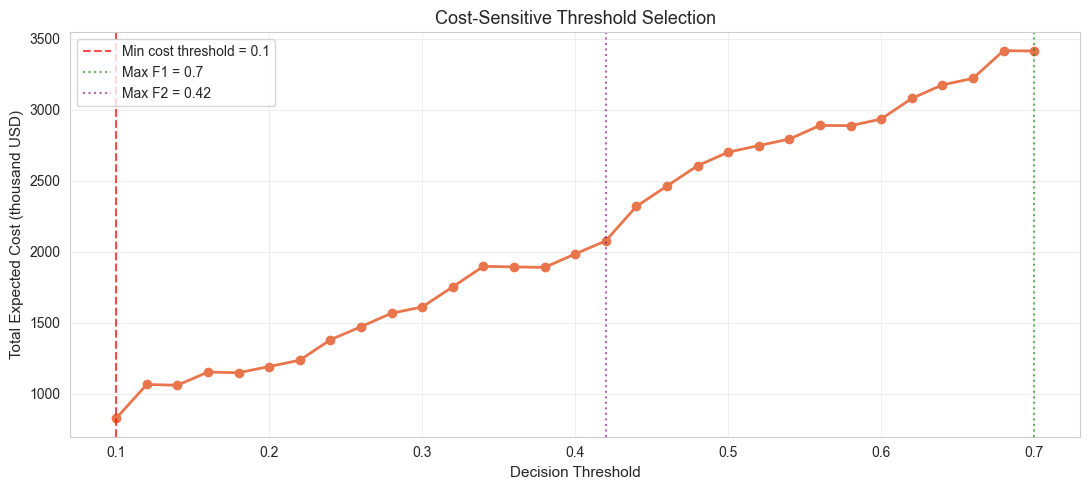

In [76]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cost_df['threshold'], cost_df['total_cost_USD']/1000,
        marker='o', color='#E8754C', lw=2)
ax.axvline(threshold_min_cost, color='red', ls='--', alpha=0.7,
           label=f'Min cost threshold = {threshold_min_cost}')
ax.axvline(threshold_best_f1, color='green',  ls=':', alpha=0.6,
           label=f'Max F1 = {threshold_best_f1}')
ax.axvline(threshold_best_f2, color='purple', ls=':', alpha=0.6,
           label=f'Max F2 = {threshold_best_f2}')
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Total Expected Cost (thousand USD)")
ax.set_title("Cost-Sensitive Threshold Selection")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/v4_cost_sensitive_threshold.png", dpi=150, bbox_inches='tight')
plt.show()

In [77]:
test_pred_min_cost = (best_test_prob >= threshold_min_cost).astype(int)
test_cost_at_optimal = expected_cost(y_test, test_pred_min_cost)
test_cost_at_default = expected_cost(y_test, (best_test_prob >= 0.5).astype(int))
test_cost_at_f1      = expected_cost(y_test, best_test_pred_f1)
test_cost_at_f2      = expected_cost(y_test, best_test_pred_f2)

cost_comparison = pd.DataFrame({
    'strategy':            ['Default (0.5)', 'Max F1', 'Max F2', 'Min Cost'],
    'threshold':           [0.5, threshold_best_f1, threshold_best_f2, threshold_min_cost],
    'test_total_cost_USD': [int(test_cost_at_default), int(test_cost_at_f1),
                            int(test_cost_at_f2), int(test_cost_at_optimal)],
    'savings_vs_default':  [0,
                            int(test_cost_at_default - test_cost_at_f1),
                            int(test_cost_at_default - test_cost_at_f2),
                            int(test_cost_at_default - test_cost_at_optimal)]
})
cost_comparison

,strategy,threshold,test_total_cost_USD,savings_vs_default
0,Default (0.5),0.50,483800,0
1,Max F1,0.70,823000,-339200
2,Max F2,0.42,389400,94400
3,Min Cost,0.10,61800,422000


## 4.19 Model Persistence

In [78]:
joblib.dump(best_model, "models/v4_best_" + best_model_name.replace(' ', '_') + ".pkl")
joblib.dump(pipeline_lr, "models/v4_lr_baseline.pkl")
joblib.dump(xgb_model, "models/v4_xgb.pkl")

metadata = {
    "project": "IBM Employee Attrition — ERP HR Module",
    "version": "4.0.0",
    "trained_at": datetime.now().isoformat(),
    "approach": "LR (baseline) vs XGBoost (main model)",
    "leakage_prevention": [
        "Data split BEFORE feature engineering",
        "Quantile thresholds learned from train only",
        "Scaling inside ImbPipeline for CV integrity",
        "No SMOTE — used class_weight / scale_pos_weight"
    ],
    "dataset": {
        "n_rows":            int(len(df)),
        "n_features_final":  len(final_features),
        "target":            "Attrition",
        "attrition_rate":    float(df[TARGET_COL].mean())
    },
    "split": {
        "train":        int(len(X_train)),
        "val":          int(len(X_val)),
        "test":         int(len(X_test)),
        "random_state": RANDOM_STATE
    },
    "best_model": best_model_name,
    "thresholds": {
        "max_f1":     float(threshold_best_f1),
        "max_f2":     float(threshold_best_f2),
        "max_recall": float(threshold_high_recall),
        "min_cost":   float(threshold_min_cost)
    },
    "test_metrics_max_f2": {
        "precision": float(precision_score(y_test, best_test_pred_f2)),
        "recall":    float(recall_score(y_test, best_test_pred_f2)),
        "f1":        float(f1_score(y_test, best_test_pred_f2)),
        "f2":        float(fbeta_score(y_test, best_test_pred_f2, beta=2)),
        "roc_auc":   float(roc_auc_score(y_test, best_test_prob))
    },
    "test_topk_recall": {
        f"top_{int(row['k_pct'])}_pct": {
            "precision_at_k": float(row['precision_at_k']),
            "recall_at_k":    float(row['recall_at_k']),
            "lift_at_k":      float(row['lift_at_k'])
        }
        for _, row in test_topk_results.iterrows()
    }
}

with open("models/v4_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

pd.Series(metadata['leakage_prevention'], name='Leakage Prevention Measures').to_frame()

,Leakage Prevention Measures
0,Data split BEFORE feature engineering
1,Quantile thresholds learned from train only
2,Scaling inside ImbPipeline for CV integrity
3,No SMOTE — used class_weight / scale_pos_weight
